# Load Tether Analysis Dataframe

This notebook demonstrates how to load and work with tether analysis data exported in XArray format from the PyFMGUI DyNaMo tether analysis tool.

The notebook covers:
1. Loading session data from NetCDF files
2. Loading analysis results from NetCDF files 
3. Basic data exploration and visualization
4. Working with the structured scientific data format

In [1]:
# Import required libraries
# import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px



In [2]:
# open csv file as dataframe
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/final/yess/batch_analysis_results/detailed_plateau_data.csv'

csv_file_path = '/Users/evillz/Data/article/final_yey/w_felix/batch_analysis_results/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)


In [3]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus
N_end_offset = 0
N_start_offset = 1


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_calc = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []
rupture_slope_arr = []
# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx
    
    print(f"\nFile {file_idx}: {filename}")
    
    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    num_plateaus = len(plateau_indices)
    
    if num_plateaus == 6:
        print ('yes')

    if num_plateaus-1 <= 1:
        num_plateaus = 0
    else: 
        num_plateaus = num_plateaus - N - 1  # Adjust for start offset

    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[:num_plateaus:-1]
    
    print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")
    
    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]
        
        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = np.round(row['delta_time']) # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ 
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            # meta_velocity = int(np.round(row['velocity_metadata'])) 
            plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_velocity_calc = plateau_velocity_meta if plateau_velocity_calc == np.nan or 0 else plateau_velocity_calc # calculated velocity 
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            rupture_slope = row['rupture_slope']  # Slope of rupture segment
            
            print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
                    delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
                    velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")
            
            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                df.loc[plateau_data.index, 'selected_velocity_meta'] = np.abs(plateau_velocity_meta)
                df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s 
                df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate
                df.loc[plateau_data.index, 'rupture_slope'] = rupture_slope

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_calc.append(np.nan if plateau_velocity_calc == 0 else np.abs(plateau_velocity_calc)) # velocity at plteau make positive since its retract
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else np.abs(plateau_velocity_meta)) # velocity at plteau make positive since its retract
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) # time of each plateau 
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) # Detachment tie 
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s) #time of each tether plateau from contact point 
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
                rupture_slope_arr.append(np.nan if rupture_slope == 0 else rupture_slope)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)




File 1: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.34.68.tdms
  Total plateaus: 4, analyzing last 1 plateaus: [np.int64(3)]
  Plateau 3: delta_avg=5.49e-11, selected=True,                     delta_time=0.00, mean_derivative=9.21e-10,                     velocity_calc=-8.09e+01, velocity_meta=100

File 2: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.33.12.98.tdms
yes
  Total plateaus: 6, analyzing last 1 plateaus: [np.int64(5)]
  Plateau 5: delta_avg=1.58e-11, selected=True,                     delta_time=0.00, mean_derivative=8.78e-10,                     velocity_calc=-7.54e+01, velocity_meta=100

File 3: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.20.70.tdms
  Total plateaus: 3, analyzing last 1 plateaus: [np.int64(2)]
  Plateau 2: delta_avg=4.65e-11, selected=True,                     delta_time=0.00, mean_derivative=8.55e-10,                     velocity_calc=-7.62e+01, velocity_meta=100

File 4: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.46.84.tdms
  Total plat

## Variable Summary

| Variable Name                | Description                                                                                 | Units                |
|------------------------------|--------------------------------------------------------------------------------------------|----------------------|
| `selected_delta_avg`         | List of average tether force values for selected plateaus                                  | Newtons (N)          |
| `selected_velocity_meta`     | List of velocity metadata values for selected plateaus                                     | µm/s                 |
| `selected_delta_time`        | List of plateau segment duration                                                           | seconds (s)          |
| `selected_slope`             | List of plateau slopes (dF/dZ) for selected plateaus                                       | N/m                  |
| `selected_tether_lifetime_m` | List of detachment distances for selected plateaus                                         | meters (m)           |
| `selected_tether_lifetime_s` | List of tether lifetimes for selected plateaus                                             | seconds (s)          |
| `loading_rate`               | loading rates (mean dF/dt) for selected plt where df=force (N),dt = dt*velocity_um_s       | N/s                  |
| `rupture_slope_arr`          | List of rupture slopes for selected plateaus                                               | N/m                  |
| `velocity_meta_clean`        | Numpy array of selected velocities, cleaned of NaN and zero values                        | µm/s                 |
| `delta_avg_clean`            | Numpy array of selected average forces, cleaned of NaN and zero values                    | Newtons (N)          |
| `force_valid_mask`           | Boolean mask for valid force/velocity data (non-NaN, non-zero, within force range)         | -                    |
| `velocity_force_filtered`    | Filtered velocities after applying `force_valid_mask`                                      | µm/s                 |
| `force_filtered`             | Filtered forces after applying `force_valid_mask`                                          | Newtons (N)          |
| `velocity_log`               | Log10 of filtered velocities                                                               | log10(µm/s)          |
| `force_log`                  | Filtered forces converted to pN                                                            | pN                   |
| `finite_mask`                | Boolean mask for finite log values                                                         | -                    |
| `velocity_log_clean`         | Cleaned log10 velocities (finite only)                                                     | log10(µm/s)          |
| `force_log_clean`            | Cleaned force values in pN (finite only)                                                   | pN                   |
| `force_df`                   | DataFrame containing filtered and cleaned velocity and force data                          | -                    |
| `means_df`                   | DataFrame containing mean force and velocity per velocity bin                              | -                    |
| `tether_force_array`         | Absolute value of selected delta_avg as numpy array                                        | Newtons (N)          |
| `tether_lifetime_s_array`    | Numpy array of selected tether lifetimes (seconds)                                         | seconds (s)          |
| `tether_lifetime_m_array`    | Numpy array of selected detachment distances (meters)                                      | meters (m)           |
| `loading_rate_array`         | Numpy array of loading rates                                                               | N/s                  |
| `tether_force_bin_labels_for_points` | List of force bin labels for each point (for binned plotting)                      | pN                   |
| `loading_rate_bin_labels_for_points` | List of loading rate bin labels for each point (for binned plotting)               | pN/s                 |

In [4]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m)
print("Contains negative values:", has_negative)

Contains negative values: False


In [5]:
# QUICK DIAGNOSIS - Test the plotting logic directly
velocity_meta_clean = np.array(selected_velocity_meta)
slope_clean = np.array(selected_slope)
delta_avg_clean = np.array(selected_delta_avg)  

main_valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    (velocity_meta_clean != 0) &
    (slope_clean != 0)
)

velocity_filtered = velocity_meta_clean[main_valid_mask]
slope_filtered = slope_clean[main_valid_mask]
delta_avg_filtered = delta_avg_clean[main_valid_mask]

vel_bins_all = np.unique(np.round(velocity_filtered).astype(int))
print(f"Available velocity bins: {vel_bins_all}")

# test for delta avg plotting logic
delta_avg_data_by_vel = []
vel_labels_delta_avg = []
for v in vel_bins_all:
    mask = np.round(velocity_filtered).astype(int) == v
    delta_avg_subset = delta_avg_filtered[mask]
    delta_avg_log = np.log10(np.abs(delta_avg_subset) * 1e6)
    delta_avg_valid = delta_avg_log[np.isfinite(delta_avg_log)]
    print(f"Velocity {v}: {len(delta_avg_subset)} raw, {len(delta_avg_valid)} valid delta_avg values")
    if len(delta_avg_valid) > 0:
        delta_avg_data_by_vel.append(delta_avg_valid)
        vel_labels_delta_avg.append(v)  

# # Test slope plotting logic
# slope_data_by_vel = []
# vel_labels_slope = []
# for v in vel_bins_all:
#     mask = np.round(velocity_filtered).astype(int) == v
#     delta_avg_subset = delta_avg_filtered[mask]
#     slope_subset = slope_filtered[mask]
#     slope_log = np.log10(np.abs(slope_subset) * 1e6)
#     slope_valid = slope_log[np.isfinite(slope_log)]
#     print(f"Velocity {v}: {len(slope_subset)} raw, {len(slope_valid)} valid slope values")
#     if len(slope_valid) > 0:
#         slope_data_by_vel.append(slope_valid)
#         vel_labels_slope.append(v)

# print(f"Final slope plot will have {len(vel_labels_slope)} velocity bins: {vel_labels_slope}")

# # Same for distance
# lifetime_m_clean = np.array(selected_tether_lifetime_m)
# main_valid_mask_dist = (
#     ~np.isnan(velocity_meta_clean) & 
#     ~np.isnan(lifetime_m_clean) &
#     (velocity_meta_clean != 0) &
#     (lifetime_m_clean > 0)
# )

# velocity_dist_filtered = velocity_meta_clean[main_valid_mask_dist]
# lifetime_m_filtered = lifetime_m_clean[main_valid_mask_dist]

# distance_data_by_vel = []
# vel_labels_distance = []
# for v in vel_bins_all:
#     mask = np.round(velocity_dist_filtered).astype(int) == v
#     distance_subset = lifetime_m_filtered[mask]
#     distance_log = np.log10(distance_subset * 1e6)
#     distance_valid = distance_log[np.isfinite(distance_log)]
#     print(f"Velocity {v}: {len(distance_subset)} raw, {len(distance_valid)} valid distance values")
#     if len(distance_valid) > 0:
#         distance_data_by_vel.append(distance_valid)
#         vel_labels_distance.append(v)

# print(f"Final distance plot will have {len(vel_labels_distance)} velocity bins: {vel_labels_distance}")

Available velocity bins: [   3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]
Velocity 3: 7 raw, 7 valid delta_avg values
Velocity 6: 12 raw, 12 valid delta_avg values
Velocity 10: 20 raw, 20 valid delta_avg values
Velocity 30: 59 raw, 58 valid delta_avg values
Velocity 60: 10 raw, 9 valid delta_avg values
Velocity 100: 127 raw, 123 valid delta_avg values
Velocity 600: 5 raw, 4 valid delta_avg values
Velocity 1000: 19 raw, 18 valid delta_avg values
Velocity 2000: 31 raw, 31 valid delta_avg values
Velocity 2300: 100 raw, 98 valid delta_avg values
Velocity 3000: 66 raw, 66 valid delta_avg values
Velocity 5010: 35 raw, 32 valid delta_avg values
Velocity 6000: 39 raw, 38 valid delta_avg values


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def safe_log10(data):
    """Compute log10 safely, avoiding -inf from zeros or negatives."""
    data = np.array(data, dtype=float)
    data[data <= 0] = np.nan
    return np.log10(data)

# Publication-style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.edgecolor': 'black',
})

In [7]:
# Filter and prepare force data
velocity_meta_clean = np.array(selected_velocity_meta)
velocity_calc_clean = np.array(selected_velocity_calc)
delta_avg_clean = np.array(selected_delta_avg)
slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm
lifetime_m_clean = np.array(selected_tether_lifetime_m)
lifetime_s_clean = np.array(selected_tether_lifetime_s)

valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    # ~np.isnan(slope_clean) &
    ~np.isnan(delta_avg_clean) &
    ~np.isnan(lifetime_m_clean) &
    ~np.isnan(lifetime_s_clean) &

    (velocity_meta_clean > 1e-6) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12) &      # <1000 pN
    (lifetime_m_clean > 0) &
    (lifetime_s_clean > 0) 
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    # (slope_clean < -1) 

)

velocity_meta_filtered = velocity_meta_clean[valid_mask]
velocity_calc_filtered = velocity_calc_clean[valid_mask]
force_filtered = delta_avg_clean[valid_mask]
slope_filtered = slope_clean[valid_mask]
tether_lifetime_m_filtered = lifetime_m_clean[valid_mask] 
tether_lifetime_s_filtered = lifetime_s_clean[valid_mask] 

# Convert to log scale for analysis
velocity_meta_log = safe_log10(velocity_meta_filtered)
velocity_calc_log = safe_log10(velocity_calc_filtered)
lifetime_m_log = safe_log10(tether_lifetime_m_filtered)
lifetime_s_log = safe_log10(tether_lifetime_s_filtered)
# slope_log = safe_log10(slope_filtered)
force_clean = np.abs(force_filtered) * 1e12 # change to pN

# Remove infinite values
finite_mask = np.isfinite(velocity_meta_log) & np.isfinite(force_clean) & np.isfinite(velocity_calc_log) & np.isfinite(slope_filtered)

# apply finite_mask
velocity_meta_log_clean = velocity_meta_log[finite_mask]
velocity_calc_log_clean = velocity_calc_log[finite_mask]
force_clean = force_clean[finite_mask]
velocity_clean = velocity_meta_filtered[finite_mask]
velocity_calc_clean = velocity_calc_filtered[finite_mask]
slope_filtered_clean = slope_filtered[finite_mask]
lifetime_m_log_clean = lifetime_m_log[finite_mask]
lifetime_s_log_clean = lifetime_s_log[finite_mask]
lifetime_m_clean = tether_lifetime_m_filtered[finite_mask]
lifetime_s_clean = tether_lifetime_s_filtered[finite_mask]  



# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity_meta': velocity_clean,
    'velocity_calc': velocity_calc_clean,
    'velocity_meta_log': velocity_meta_log_clean,
    'velocity_calc_log': velocity_calc_log_clean,
    'force_clean': force_clean,
    'slope': slope_filtered_clean,
    'lifetime_m_log': lifetime_m_log_clean,
    'lifetime_s_log': lifetime_s_log_clean,
    'lifetime_m_clean': lifetime_m_clean,
    'lifetime_s_clean': lifetime_s_clean    
})


### Felix comments
1. try with only the last tether
2. Check consideration of tether

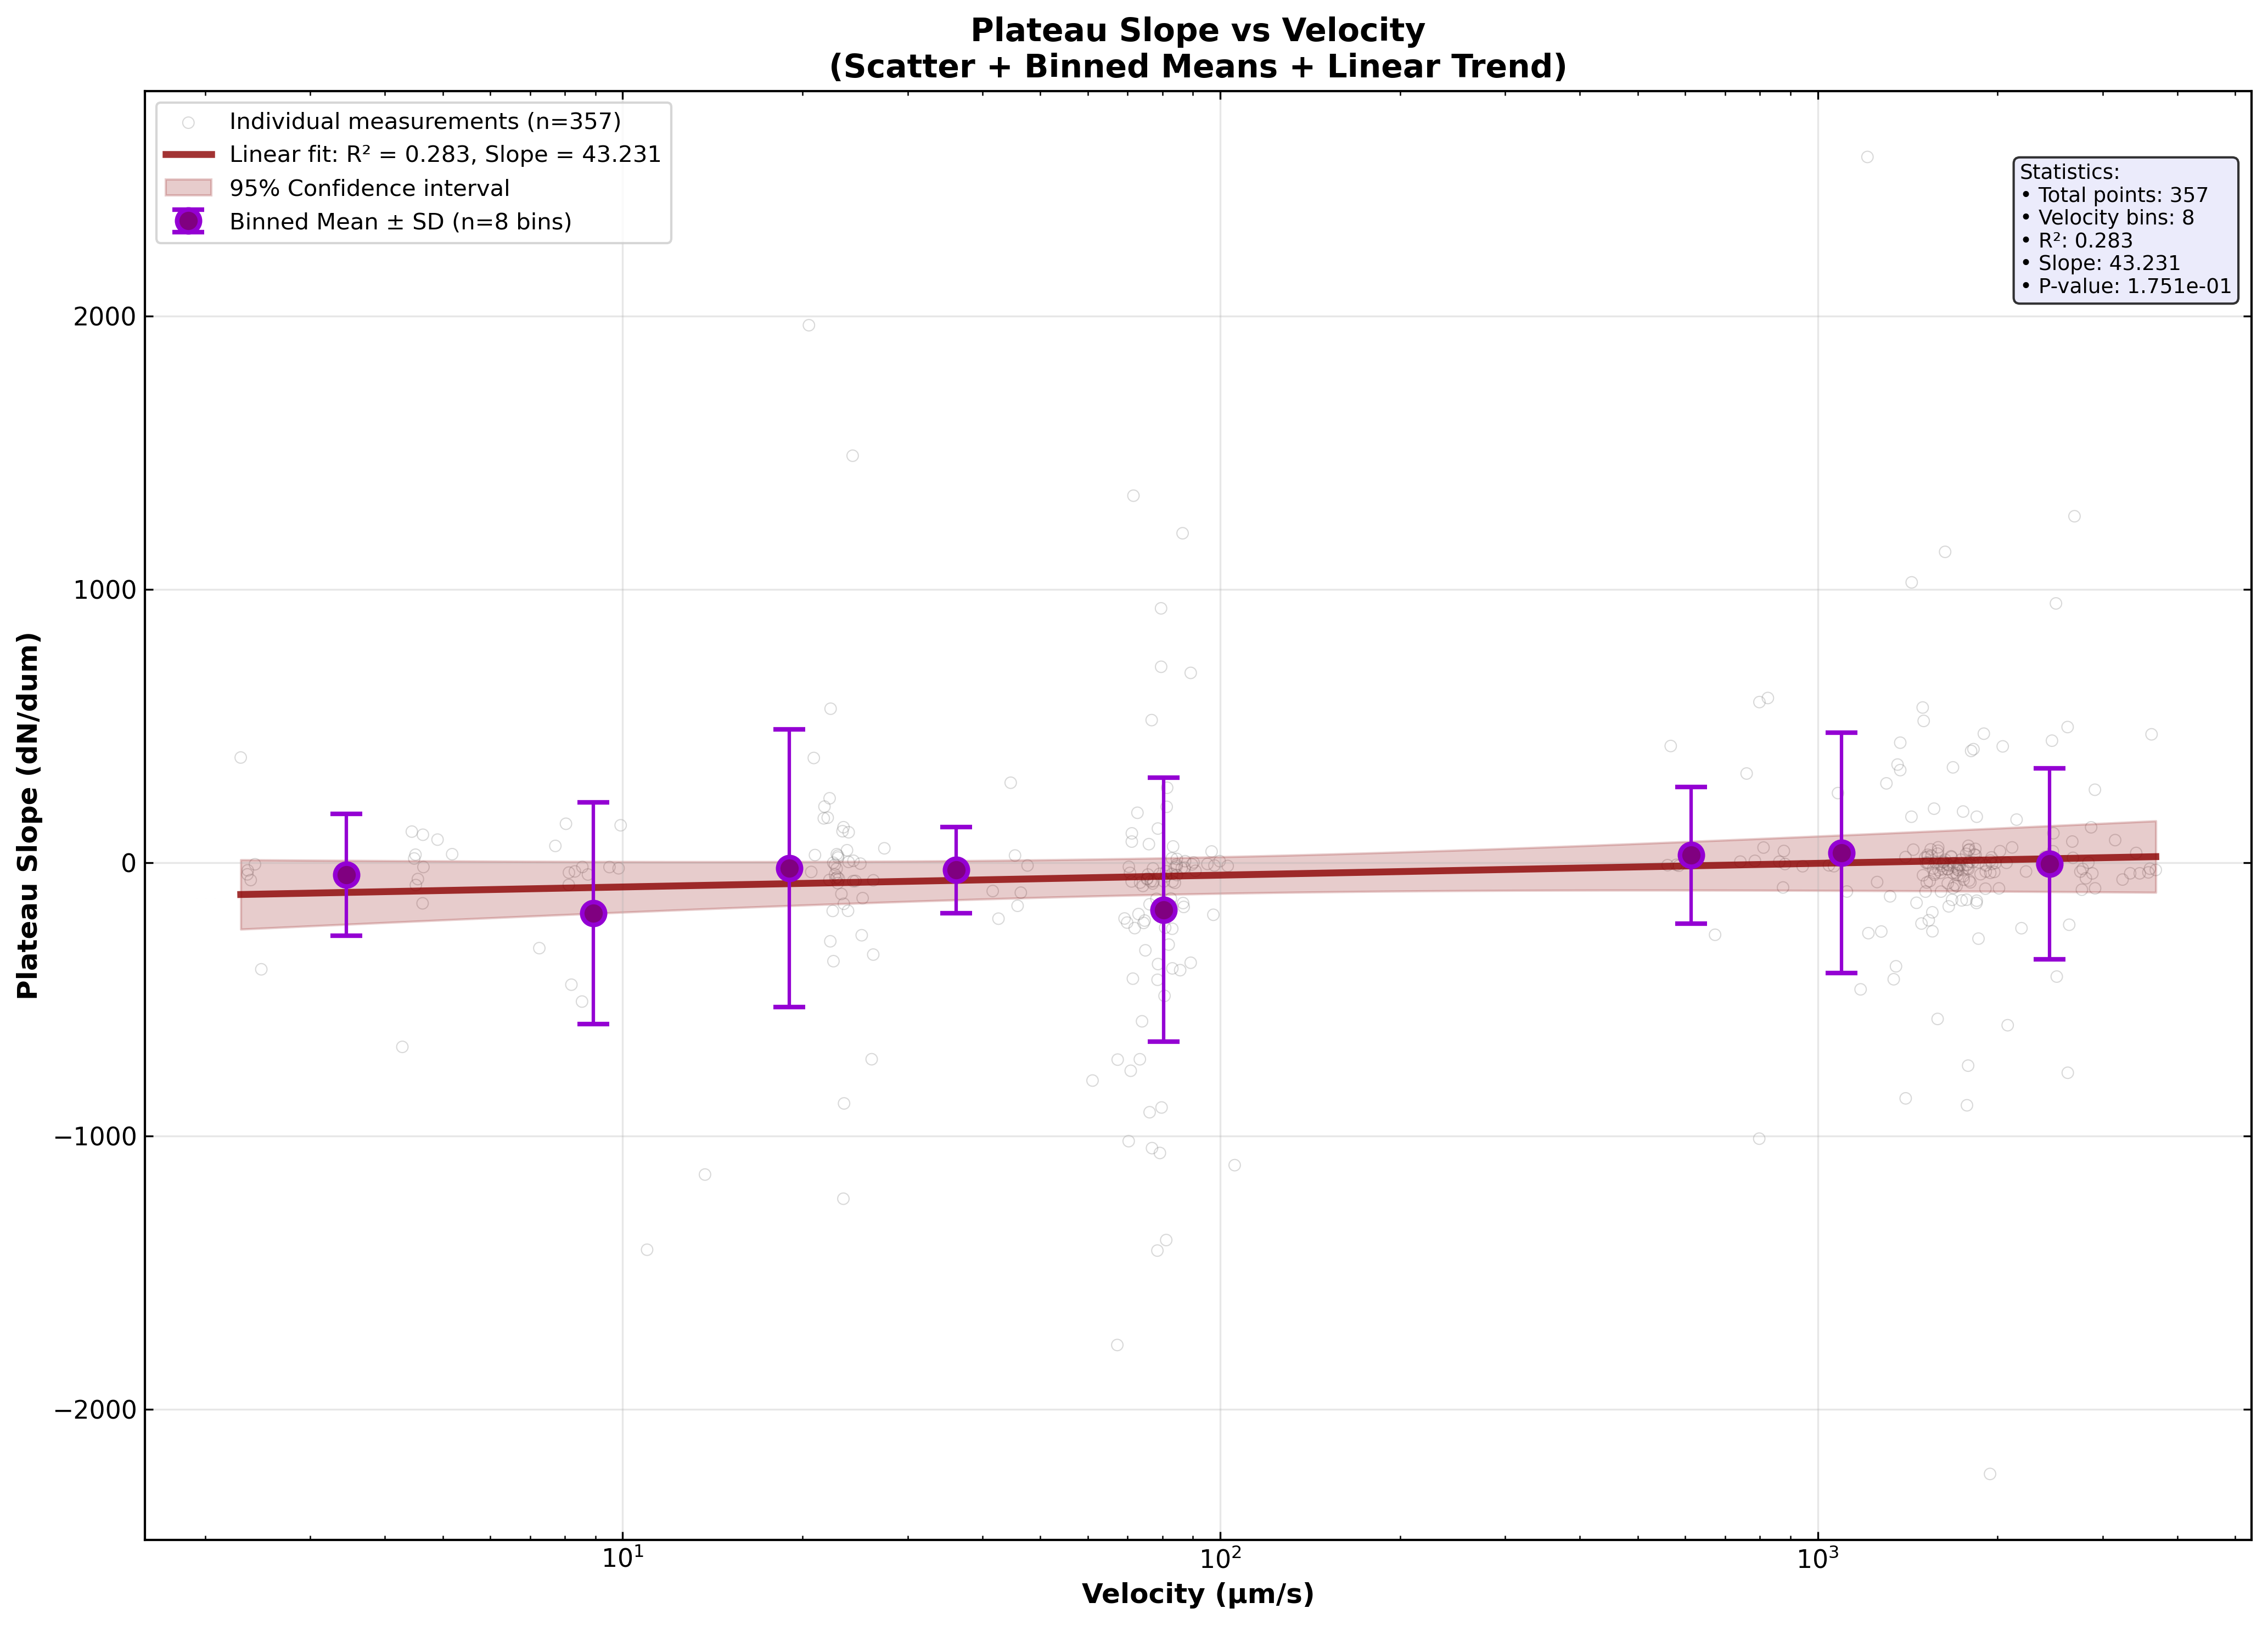

Slope analysis: 357 points, 8 bins


In [8]:
# 1. Plateau Slope vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# # Filter and prepare slope data
# velocity_meta_clean = np.array(selected_velocity_calc)
# slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm

# # Basic data filtering
valid_mask = (
    # ~np.isnan(velocity_meta_clean) & 
    # ~np.isnan(slope_clean) &
    # (velocity_meta_clean > 1e-6)
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    (slope_filtered_clean > -4000) 
)

# velocity_filtered = velocity_meta_clean[valid_mask]
# slope_filtered = slope_clean[valid_mask]
# slope_log = slope_filtered  

# # Remove infinite values
# finite_mask = np.isfinite(slope_log)
# velocity_filtered = velocity_filtered[finite_mask]
# slope_log = slope_log[finite_mask]

# Create DataFrame
slope_df = pd.DataFrame({
    'velocity': velocity_calc_clean[valid_mask],
    'slope_log': slope_filtered_clean[valid_mask],
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(slope_df['velocity'], slope_df['slope_log'], 
          alpha=0.3, s=25, color='none', edgecolors='grey', linewidth=0.5,
          label=f'Individual measurements (n={len(slope_df)})')

# 2. Create velocity bins and calculate means
num_bins = 9
velocity_min, velocity_max = slope_df['velocity'].min(), slope_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
slope_df['bin_idx'] = np.digitize(slope_df['velocity'], bin_edges) - 1
slope_df['bin_idx'] = np.clip(slope_df['bin_idx'], 0, num_bins - 1)

means_df = slope_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    slope_mean=('slope_log', 'mean'),
    slope_std=('slope_log', 'std'),
    count=('slope_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 3]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['slope_mean'], 
               yerr=means_df['slope_std'], 
               fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
               markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)
    
# # --- SHOW BIN LIMITS ---
# for edge in bin_edges:
#     ax.axvline(edge, color='grey', linestyle='--', alpha=0.5, zorder=0)
#     # Optionally annotate the bin edge value
#     ax.text(edge, ax.get_ylim()[1], f"{edge:.1f}", rotation=90, va='bottom', ha='right', fontsize=8, color='grey')


# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['slope_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Plateau Slope (dN/dum)", fontsize=12, fontweight='bold')
ax.set_title("Plateau Slope vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Insufficient data for trend"""

ax.text(0.89, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Slope analysis: {len(slope_df)} points, {len(means_df)} bins")

# user spearman fit or pearson fit -PHP

Data velocity range: 2.3 - 3680.7 µm/s
Using bin edges: [   2    3    6   10   50  100 3000 6000 7000]


<Figure size 2100x1500 with 0 Axes>

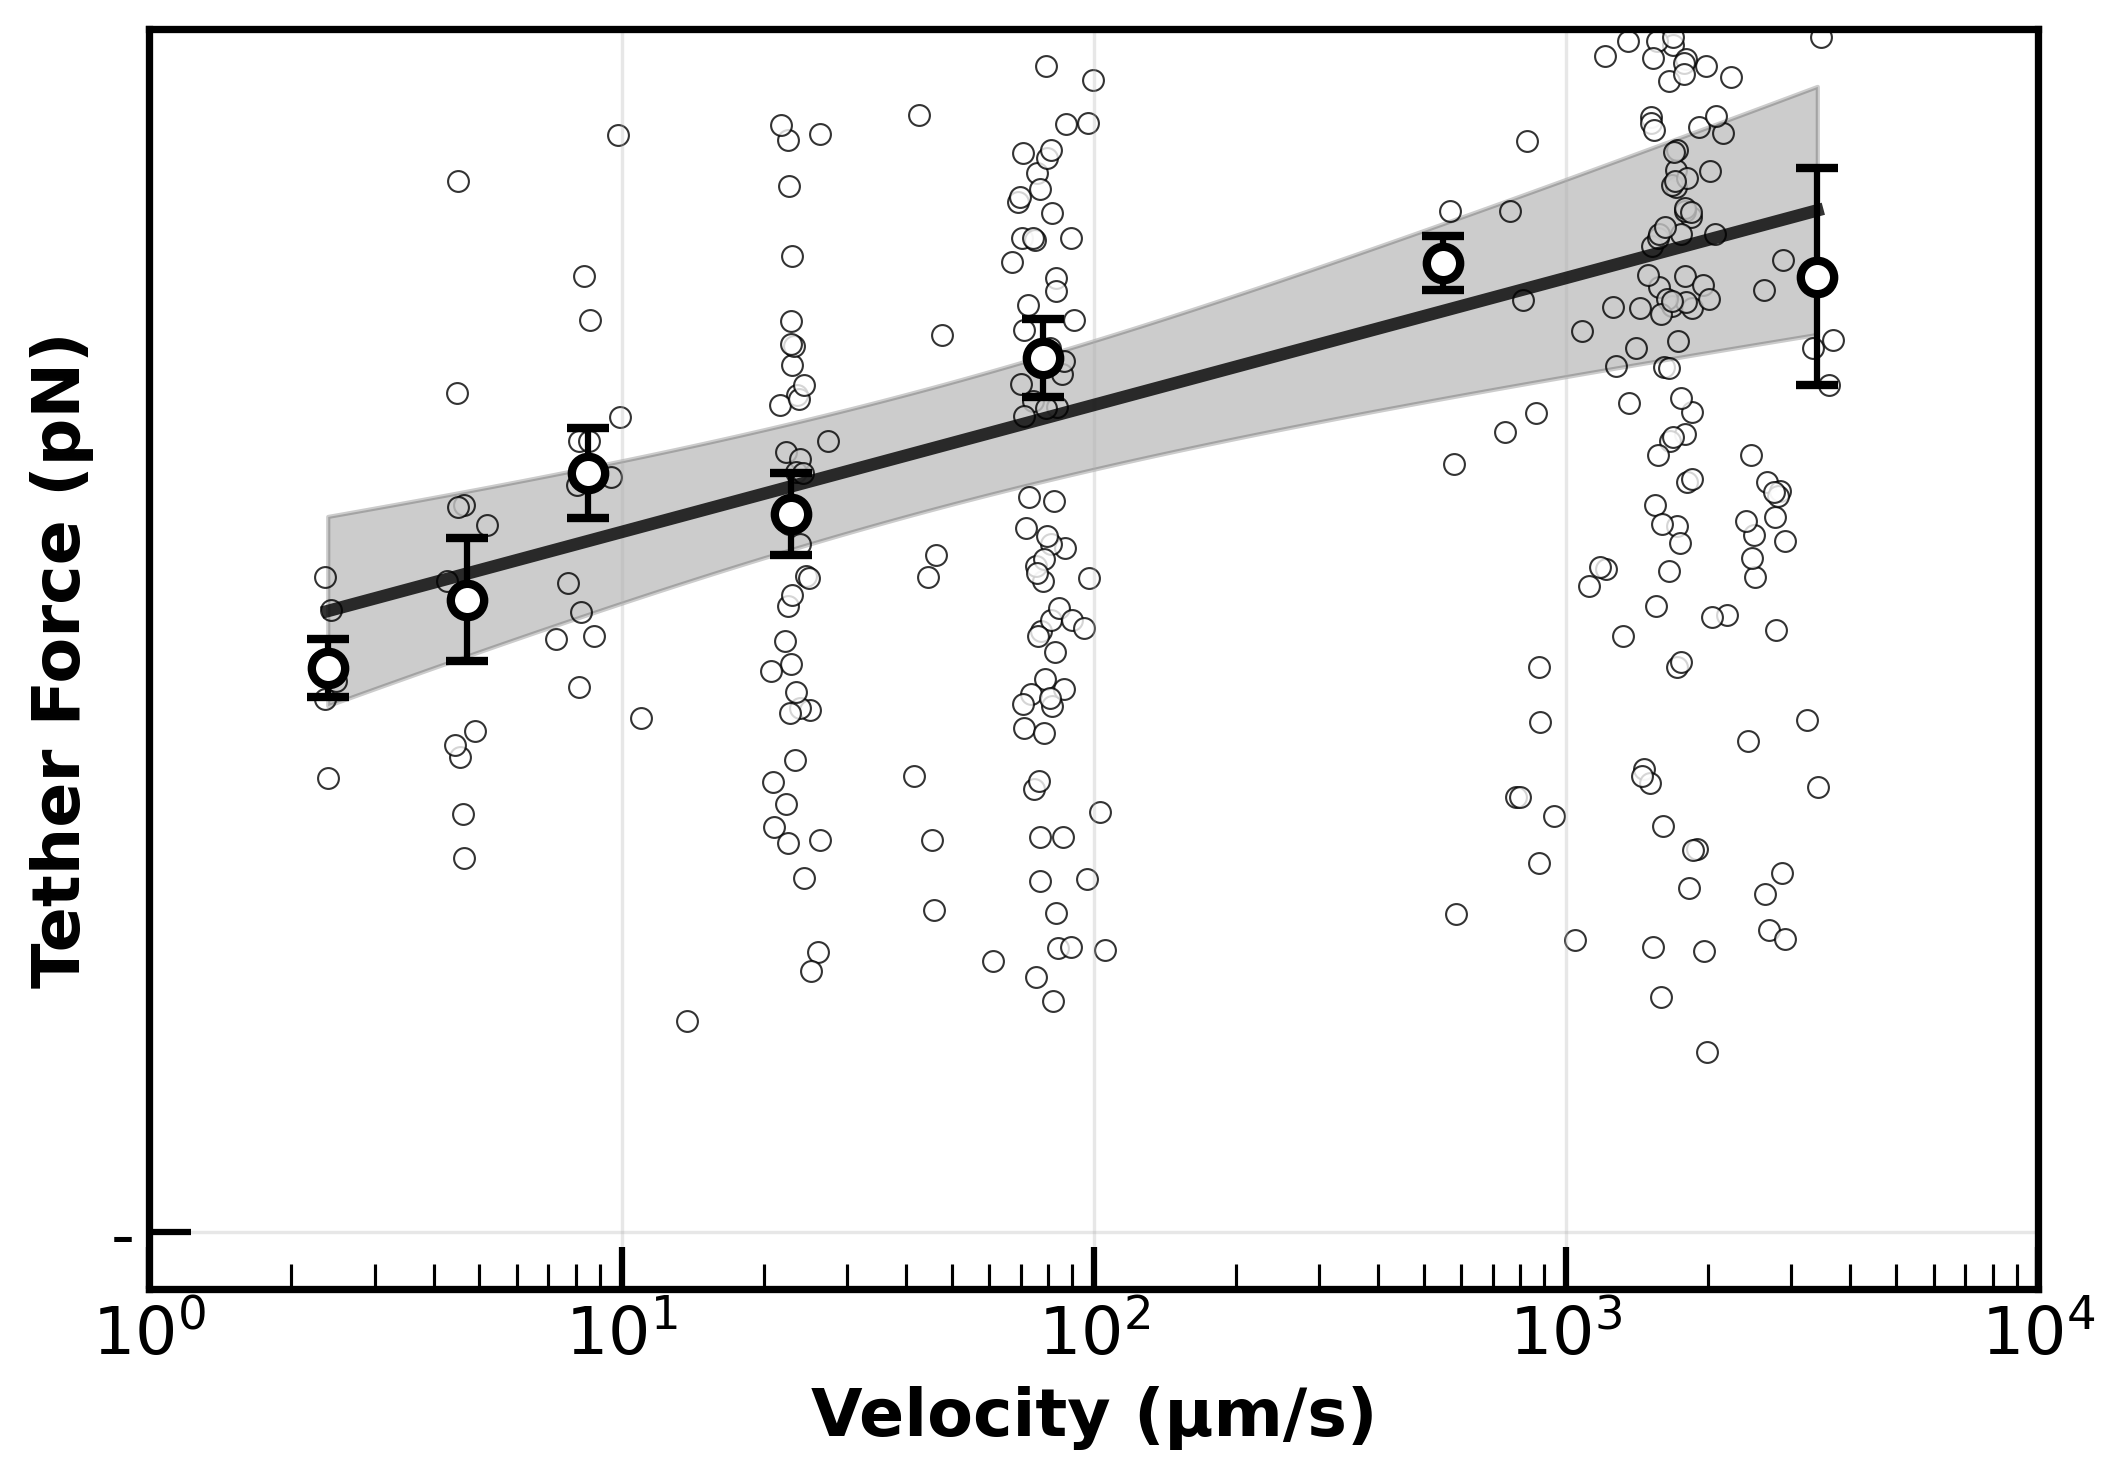

/Users/evillz/Data/article/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_Tethe.svg


In [9]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(7, 5), dpi=300)
plt.rcParams.update({
    'axes.linewidth': 1.75,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 10,  # Length of major ticks
    "ytick.major.size": 10,

    "xtick.minor.size": 6,  # Length of minor ticks
    "ytick.minor.size": 6,

    "xtick.major.width": 1.5,  # Width of major ticks
    "ytick.major.width": 1.5,

    "xtick.minor.width": 0.75,  # Width of minor ticks
    "ytick.minor.width": 0.75,
    "xtick.top": False,  # Enable top ticks
    "ytick.right": False  # Enable right ticks
})

# Main plot
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.8, s=25, color='white', edgecolors='black', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()
# First, check your actual data range
print(f"Data velocity range: {force_df['velocity_calc'].min():.1f} - {force_df['velocity_calc'].max():.1f} µm/s")

# Define your custom velocity bin edges (µm/s)
velocity_bin_edges = np.array([2, 3, 6, 10, 50, 100, 3000, 6000, 7000]) 

# 3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]

# OR better: Set the upper bound based on your max velocity
max_velocity = force_df['velocity_calc'].max()
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges, right = True) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]
# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_sem=('force_clean', 'sem'),

    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()


# Filter out bins with too few points
# means_df_2 = means_df_2[means_df_2['force_count'] != 23]


# 3. Plot means with error bars (standard deviation) using bin centers
ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
           yerr=means_df_2['force_sem'], 
           fmt='o', color='white', markersize=8, markeredgecolor='black', 
           markeredgewidth=2, ecolor='black', capsize=5, capthick=1.5,
           label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)

# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'black','-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='black',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
# ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            # fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
# ax.legend(fontsize=14)

# # Add statistics text
# stats_text = f"""Statistics (Binned mean-based fit):
# • Total points: {len(force_df)}
# • Velocity bins: {len(means_df_2)}
# • Velocity range: {means_df_2['velocity_bin_center'].min():.1f} - {means_df_2['velocity_bin_center'].max():.1f} µm/s
# • Trend p-value: {p_value:.3e}
# • Slope: {slope_coeff:.3f}
# • R²: {r_value**2:.3f}"""

# ax.text(0.02, 0.8, stats_text, transform=ax.transAxes, fontsize=9,
#         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

plt.tight_layout()
plt.xlim(left = 10e-1)
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=16, fontweight='bold')
ax.set_xlim(1,10000)
ax.tick_params(axis='x', labelsize=16)  # X-axis tick labels
ax.tick_params(axis='y', labelsize=16)  # Y-axis tick labels
plt.show()

# print(f"Force analysis complete:")
# print(f"  - Individual data points: {len(force_df)}")
# print(f"  - Velocity bins used for trend: {len(means_df_2)}")
# print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
# print(f"  - Slope coefficient: {slope_coeff:.3f}")
# print(f"  - P-value: {p_value:.3e}")
# print(f"  - Bin information:")
# for i, row in means_df_2.iterrows():
#     print(f"    Bin {i+1}: {row['bin_label']} ({row['force_count']} points), center={row['velocity_bin_center']:.1f} µm/s, count={row['force_count']} points")
#     # print(f"    Bin {i}: center={row['velocity_bin_center']:.1f} µm/s, count={row['force_count']} points")


# save as svg file
# save as svg file
save_plots = False
dir_path = '/Users/evillz/Data/article/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_Tethe.svg')
print (fig_path)
if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    # plt.show()

In [10]:
from matplotlib.ticker import MultipleLocator, LogLocator, AutoMinorLocator, FixedLocator
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from matplotlib import gridspec
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, lognorm
import numpy as np
from statistics import geometric_mean
def make_hist_dfs_AFS(df_raw, **kwargs):
    plt.rcParams.update({'font.size': 18, 'font.family': 'Times New Roman'})

    df_raw.dropna(subset=['log_lr_bin'], inplace=True)
    N_bins = len(df_raw['log_lr_bin'].unique())
    if N_bins == 7:
        N_plot = N_bins+1
    else:
        N_plot = N_bins

    row, columns = compute_grid(N_plot)
    fig, axes = plt.subplots(
        row, columns, figsize=(columns*4, row*4), sharex=True)
    # Plot each histogram
    # fig.suptitle("rupture force histograms SA-B ",fontsize =10)
    ax_liner_arr = axes.flatten()
    temp_gauss = []
    temp_bimod = []
    df_afs_avg = pd.DataFrame()

    average_rup_afs_hist = np.zeros(N_bins)
    average_ldr_afs_hist = np.zeros(N_bins)
    std_ldr_afs_hist = np.zeros(N_bins)
    std_upper_lr = np.zeros(N_bins)
    std_lower_lr = np.zeros(N_bins)
    std_rup_afs_hist = np.zeros(N_bins)
    mode_rup_afs_hist = np.zeros(N_bins)
    sem_rup_afs_hist = np.zeros(N_bins)
    sem_ldr_afs_hist = np.zeros(N_bins)
    std_bimodal_rup_force = np.zeros(N_bins)
    sem_bimodal_rup_force = np.zeros(N_bins)

    avg_bi_modal = np.zeros(N_bins)

    avg_gauss_arr = np.zeros(N_bins)
    std_gauss_arr = np.zeros(N_bins)
    sem_gauss_arr = np.zeros(N_bins)

    for name, df_bin in df_raw.groupby(by='log_lr_bin'):
        print(int(name)-1)
        i = int(name)

        if i < len(ax_liner_arr):

            ax = ax_liner_arr[i]
            ldr_temp = geometric_mean(df_bin['velocity_meta'])
            mantissa, exponent = f"{ldr_temp:.1e}".split("e")
            latex_formatted = f"${mantissa} \\times 10^{{{int(exponent)}}}$ pN/s"

            # ax.hist(df_bin['rup_force'],**kwargs)

            ax.set_title(latex_formatted, fontsize=20)
            total_freq = len(df_bin['force_clean'])
            n, bins, patches = ax.hist(
                df_bin['force_clean'], label=f'size = {total_freq}', **kwargs)
            bins_ft = (bins[1:]+bins[:-1])/2  # for len(x)==len(y)

            # ax.legend(frameon=False,fontsize = 15)
            ax.legend(handlelength=0, handletextpad=0.0, frameon=False)
            xmin, xmax = plt.xlim()
            xmax = 60
            xmin, xmax = -2, 120
            mu, std = norm.fit(df_bin['force_clean'])

            mode_index = n.argmax()
            modal_force = (bins[mode_index] + bins[mode_index+1])/2
            print(f'the mode froce :{modal_force}')

            x_p = np.linspace(xmin, xmax, 100)
            p = norm.pdf(x_p, mu, std)

            # ax.plot(x_p, p, 'k',color = 'black', linewidth=2)
            # #ax.set_xlim(-10,80)
            # ax.axvline(mu,color= 'black')
            temp_gauss.append(mu)

            try:
                p0_gauss = [
                    0.350*np.mean(df_bin['force_clean']), 0.35*np.std(df_bin['force_clean']), max(n)]

                popt, pcov = curve_fit(gauss, bins_ft, n, p0=p0_gauss, bounds=([0, 0, 0], [
                                       120, 20, 2*max(n)]))  # <--- leave out the first estimation of the parameters

                x_p = np.linspace(-10, xmax, 120)

                expected = (mu, std, 10, 2*std, 10)
                bounds = (0, [1000, 1000, 1000, 1000, 1000])
                expected = (0.5*mu, std, 1, std, 0)
                bounds = (0, [100, 100, 20, 200, 100])
                expected = (0.5*mu, std, max(n), std, min(n))
                bounds = (0, [100, 100, 2*max(n), 200, 2*max(n)])

                params, cov = curve_fit(
                    bimodal, bins_ft, n, expected, bounds=bounds)
                ax.plot(x_p, bimodal(x_p, *params), color='red',linestyle= '--',alpha = 1, lw=3.5,zorder=1)
                ax.axvline(params[0],color = 'red')

                ax.plot(x_p, gauss(x_p, *popt), color='tab:blue',
                        linestyle='--', linewidth=2)
                ax.set_xlim(xmin, 120)
                ax.axvline(popt[0], color='tab:blue')
                ax.xaxis.set_major_locator(MultipleLocator(10))
                # ...and individual Gauss curves
                gauss_1_params = params[:3]
                gauss_2_params = [2*params[0], params[3], params[4]]
                temp_bimod.append(params[0])

                avg_bi_modal[i] = params[0]
                std_bimodal_rup_force[i] = params[1]
                sem_bimodal_rup_force[i] = params[1] / \
                    np.sqrt(len(df_bin['velocity_meta']))

                avg_gauss_arr[i] = popt[0]
                std_gauss_arr[i] = popt[1]
                sem_gauss_arr[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))

            except RuntimeError:
                print(f'didnt work: {name}')
                avg_bi_modal[i] = mu
                std_bimodal_rup_force[i] = std
                sem_bimodal_rup_force[i] = std 
            # ax.set_xlabel("Value")
            # ax.set_ylabel("Frequency")

        # Geometric mean and geometric SD
        log_data = np.log(df_bin['velocity_meta'].to_numpy())
        log_mean = log_data.mean()
        log_std = log_data.std()
        geo_mean = np.exp(log_mean)
        average_ldr_afs_hist[i] = geo_mean
        std_lower_lr[i] = geo_mean - np.exp(log_mean - log_std)
        std_upper_lr[i] = np.exp(log_mean + log_std) - geo_mean

        average_rup_afs_hist[i] = popt[0]

        std_rup_afs_hist[i] = popt[1]
        sem_rup_afs_hist[i] = popt[1]/np.sqrt(len(df_bin['velocity_meta']))
        std_ldr_afs_hist[i] = np.std(np.log(df_bin['velocity_meta']))
        sem_ldr_afs_hist[i] = std_ldr_afs_hist[i]/np.sqrt(len((df_bin['velocity_meta'])))
        mode_rup_afs_hist[i] = modal_force
    # Adjust layout
    plt.tight_layout()
    # plt.show()

    temp_afs_avg_dict = {'rup_force': average_rup_afs_hist[:], 'avg_LDR': average_ldr_afs_hist[:], 'LDR': average_ldr_afs_hist[:],
                         'std_rup_force': std_rup_afs_hist, 'sem_rup_force': sem_rup_afs_hist,
                         'STD_LDR': std_ldr_afs_hist, 'sem_LDR': sem_ldr_afs_hist,
                         'bi_modal': avg_bi_modal, 'std_bimodal': std_bimodal_rup_force, 'sem_bi_modal': sem_bimodal_rup_force, 'avg_gauss': avg_gauss_arr, 'std_gauss': std_gauss_arr, 'sem_gauss': sem_gauss_arr,
                         'ldr_upper': std_upper_lr, 'ldr_lower': std_lower_lr}

    df_afs_avg = pd.DataFrame(temp_afs_avg_dict)
    return fig, df_afs_avg

def compute_grid(n):
    # Find the factors of n
    factors = [(i, n // i)
               for i in range(1, int(math.sqrt(n)) + 1) if n % i == 0]
    # Pick the factor pair with the smallest difference (to make the grid as square as possible)
    rows, cols = min(factors, key=lambda x: abs(x[0] - x[1]))
    return rows, cols


def gauss(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

    # return A*np.exp(-(x-mu)**2/(2*sigma**2))
# TODO get the mean from the a initial gaussian fit and then use it a inital parameter for the bimodel fit


def bimodal(x, mu1, sigma1, A1, sigma2, A2):
    return gauss(x, mu1, sigma1, A1)+gauss(x, 2*mu1, sigma2, A2)

-1
the mode froce :32.0
0
the mode froce :48.0
1
the mode froce :32.0
2
the mode froce :32.0
3
the mode froce :20.0
4
the mode froce :76.0
5
the mode froce :44.0


/var/folders/kc/jykhdgwx4p3696y51hzh6j3r0000gn/T/ipykernel_95812/3454761807.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, df_bin in df_raw.groupby(by='log_lr_bin'):


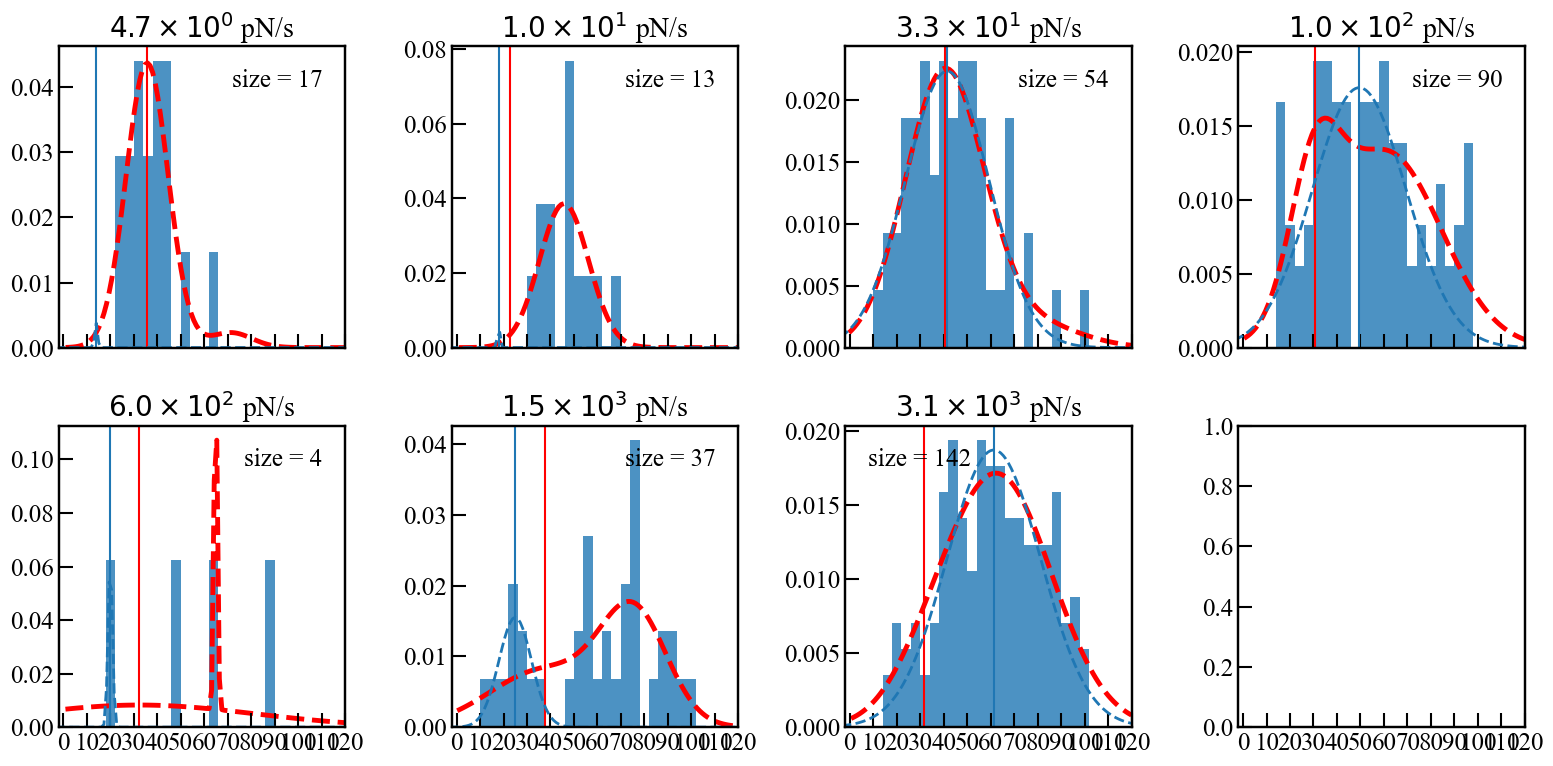

In [11]:
force_df['log_LR'] = np.log(force_df['velocity_meta'])

N_bins_afs = 7
bin_label_afs = []
for i in range(N_bins_afs):

    bin_label_afs.append(f"{i}")  # = ['1','2','3','4','5','6','7']

force_df["log_lr_bin"] = pd.cut(
    force_df['log_LR'], bins=len(bin_label_afs), labels=bin_label_afs)


# bin_label_afs = []
# for i in range(N_bins_afs):

#     bin_label_afs.append(f"{i+1}")  # = ['1','2','3','4','5','6','7']

# force_df["log_lr_bin"] = pd.cut(
#     force_df['log_LR'], bins=len(bin_label_afs), labels=bin_label_afs)


# if use_bas_bool:
#     # pooling hte BAs data into one bin
#     force_df["log_lr_bin"] = force_df["log_lr_bin"].replace({"8": "7"})

binwidth_afs = 4
bins_afs = range(-10, 120, binwidth_afs)

# binwidth_afs =5
# bins_afs=range(-5, 80 , binwidth_afs)
# binwidth_afs =3
# bins_afs=range(-6, 81 , binwidth_afs)

# Define kwargs for customization
plot_kwargs = {
    'color': 'tab:blue',
    'alpha': 0.8,
    'density': True,
    'bins': bins_afs

}
fig_dist_afs, df_afs_avg = make_hist_dfs_AFS(force_df, **plot_kwargs)
# fig_dist_afs.suptitle(f'AFS SA-B rup force dist _{LDR_choice}')
# Place the labels dynamically
# fig_dist_afs.savefig(f'{save_final_fig_plts}AFS_histograms.png')
# fig_dist_afs.savefig(f'{save_final_fig_plts}AFS_histograms.svg')

# fig_dist_afs.text(x_label_position, x_margin, 'Unbinding force (pN)', ha='center', fontsize=20)
# fig_dist_afs.text(y_margin, y_label_position, 'Counts', va='center', rotation='vertical', fontsize=20)

# Adjust layout to avoid overlap
# fig_dist_afs.tight_layout(rect=[y_margin + 0.05, x_margin + 0.05, 1, 1])

plt.show()

Saved: /Users/evillz/Data/article/figures/tether_force_vs_loading_rate.svg


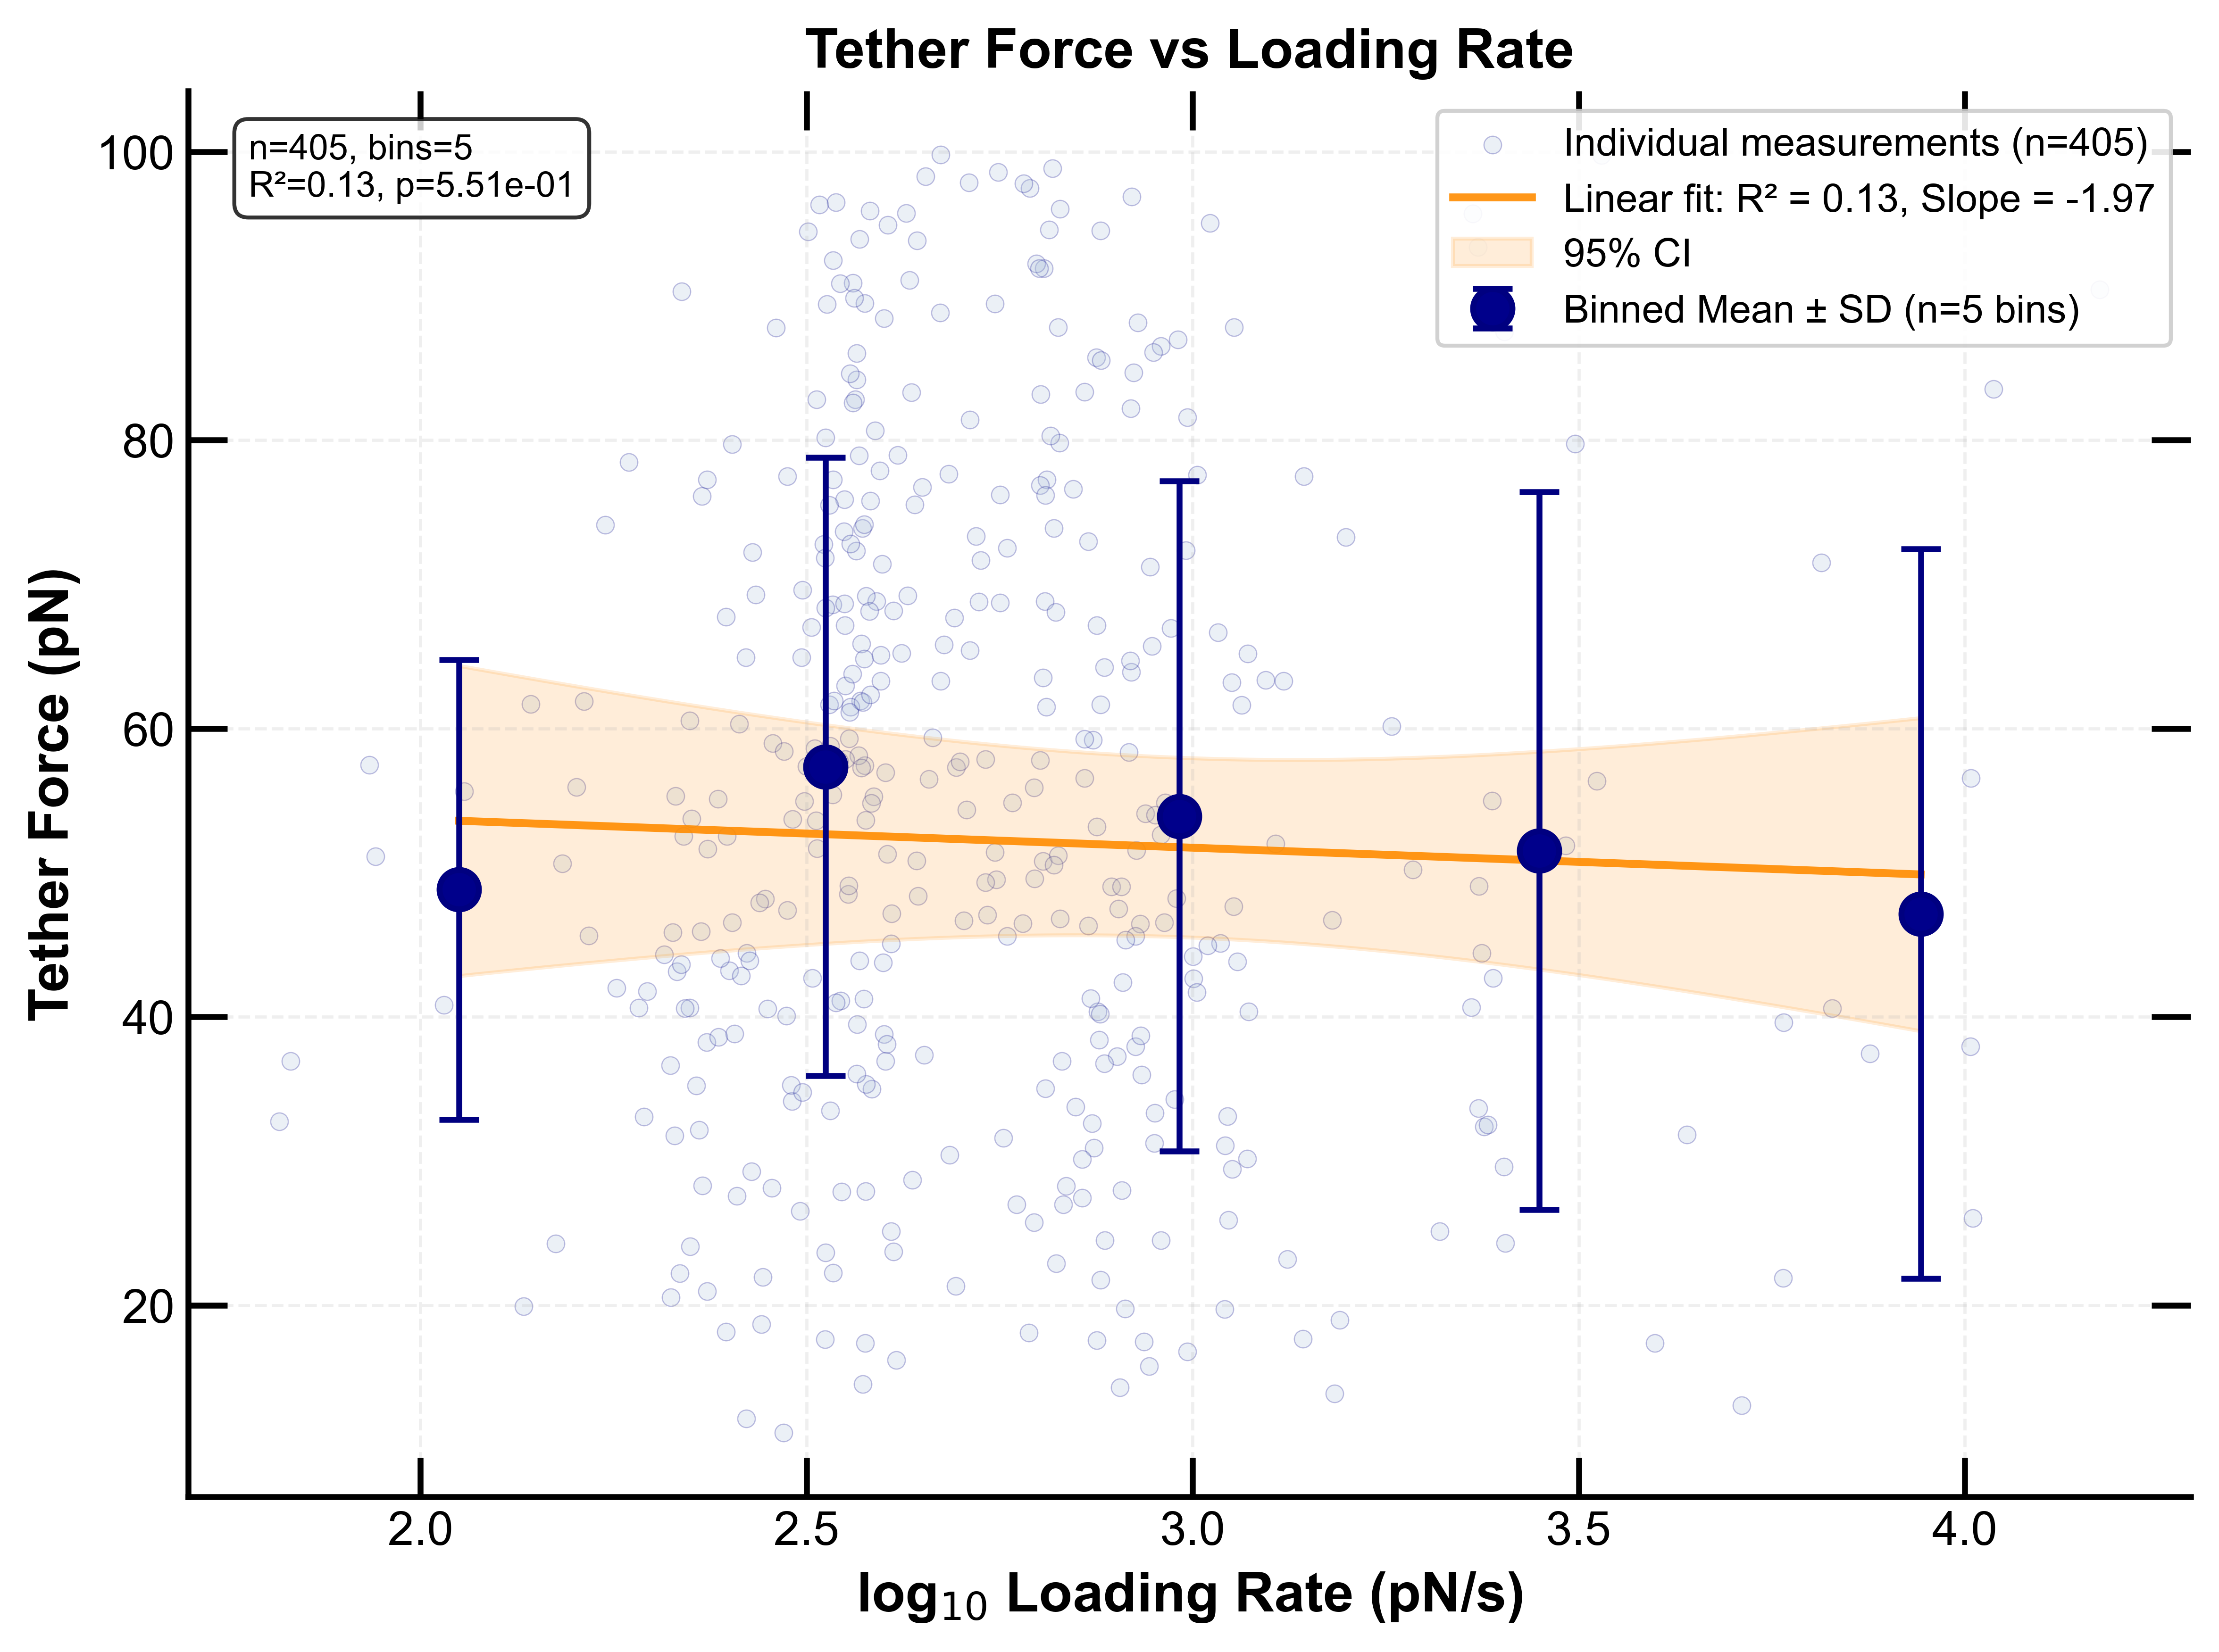


Tether Force vs Loading Rate Analysis:
  - Total points: 405
  - Bins: 5
  - R²: 0.130
  - Slope: -1.965
  - P-value: 5.507e-01


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os

# Publication-style settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'axes.linewidth': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

# Create publication-quality figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=600)

# Remove NaN values and prepare data
loading_rate_array = np.array(loading_rate)
tether_force_array = np.array(selected_delta_avg)

valid_mask = ~(np.isnan(loading_rate_array) | np.isnan(tether_force_array))
loading_rate_clean = loading_rate_array[valid_mask]
tether_force_clean = tether_force_array[valid_mask]

# Create DataFrame
loading_bins_df = pd.DataFrame({
    'loading_rate_log': np.log10(loading_rate_clean * 1e12),  # Convert to pN/s
    'tether_force': np.abs(tether_force_clean) * 1e12  # Convert to pN
})

# Remove invalid values
loading_bins_df = loading_bins_df[
    np.isfinite(loading_bins_df['loading_rate_log']) & 
    np.isfinite(loading_bins_df['tether_force']) &
    (loading_bins_df['tether_force'] > 10) &  # >10 pN
    (loading_bins_df['tether_force'] < 100)   # <100 pN
]

# 1. Scatter plot with better transparency
ax.scatter(loading_bins_df['loading_rate_log'], 
          loading_bins_df['tether_force'], 
          alpha=0.25, s=20, color='lightsteelblue', 
          edgecolors='darkblue', linewidth=0.3,
          label=f'Individual measurements (n={len(loading_bins_df)})')

# 2. Create bins and calculate statistics
num_bins = 5
loading_min = loading_bins_df['loading_rate_log'].min()
loading_max = loading_bins_df['loading_rate_log'].max()
loading_bin_edges = np.linspace(loading_min, loading_max, num_bins + 1)

loading_bins_df['bin_idx'] = np.digitize(
    loading_bins_df['loading_rate_log'], loading_bin_edges) - 1
loading_bins_df['bin_idx'] = np.clip(
    loading_bins_df['bin_idx'], 0, num_bins - 1)

# Calculate binned statistics
means_df = loading_bins_df.groupby('bin_idx').agg(
    loading_center=('loading_rate_log', lambda x: (x.min() + x.max()) / 2),
    force_mean=('tether_force', 'mean'),
    force_std=('tether_force', 'std'),
    count=('tether_force', 'count')
).reset_index()

# Filter bins with sufficient data
means_df = means_df[means_df['count'] >= 3]

# 3. Plot binned means with error bars
ax.errorbar(means_df['loading_center'], means_df['force_mean'], 
           yerr=means_df['force_std'], 
           fmt='o', color='darkblue', markersize=10, 
           markeredgecolor='navy', markeredgewidth=1.5,
           ecolor='navy', capsize=5, capthick=1.5,
           label=f'Binned Mean ± SD (n={len(means_df)} bins)', 
           zorder=5)

# 4. Fit and plot linear trend
if len(means_df) >= 3:
    x_data = means_df['loading_center']
    y_data = means_df['force_mean']
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # Generate trend line
    x_trend = np.linspace(x_data.min(), x_data.max(), 100)
    y_trend = intercept + slope * x_trend
    
    ax.plot(x_trend, y_trend, 'darkorange', linewidth=2, alpha=0.9,
           label=f'Linear fit: R² = {r_value**2:.2f}, Slope = {slope:.2f}')
    
    # Add 95% confidence interval
    from scipy import stats as scipy_stats
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_data - (intercept + slope * x_data)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (x_trend - np.mean(x_data))**2 / 
                             np.sum((x_data - np.mean(x_data))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, 
                   alpha=0.15, color='darkorange',
                   label='95% CI')

# Formatting for publication
ax.set_xlabel("log$_{10}$ Loading Rate (pN/s)", fontsize=14, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=14, fontweight='bold')
ax.set_title("Tether Force vs Loading Rate", fontsize=14, fontweight='bold')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Grid and legend
ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(fontsize=10, framealpha=0.9, loc='best')

# Compact statistics text
stats_text = (f"n={len(loading_bins_df)}, bins={len(means_df)}\n"
             f"R²={r_value**2:.2f}, p={p_value:.2e}")
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, 
       fontsize=9, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, pad=0.4))

plt.tight_layout()

# Save as SVG for publication
save_plots = True
dir_path = '/Users/evillz/Data/article/figures'
fig_path = os.path.join(dir_path, 'tether_force_vs_loading_rate.svg')

if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    fig.savefig(fig_path.replace('.svg', '.pdf'), format='pdf', dpi=600, transparent=True)
    print(f"Saved: {fig_path}")

plt.show()

print(f"\nTether Force vs Loading Rate Analysis:")
print(f"  - Total points: {len(loading_bins_df)}")
print(f"  - Bins: {len(means_df)}")
print(f"  - R²: {r_value**2:.3f}")
print(f"  - Slope: {slope:.3f}")
print(f"  - P-value: {p_value:.3e}")

Data velocity range: 2.3 - 3680.7 µm/s
Using bin edges: [   2    3    6   10   50  100 3000 6000 7000]
/Users/evillz/Data/article/figures/fcurve_thp1_cell1_ret_03ums__2025.07.01_17.27.06.69_TetherForceVsVelocity.svg
Force analysis complete: R²=0.867, Slope=7.884, p=2.298e-03


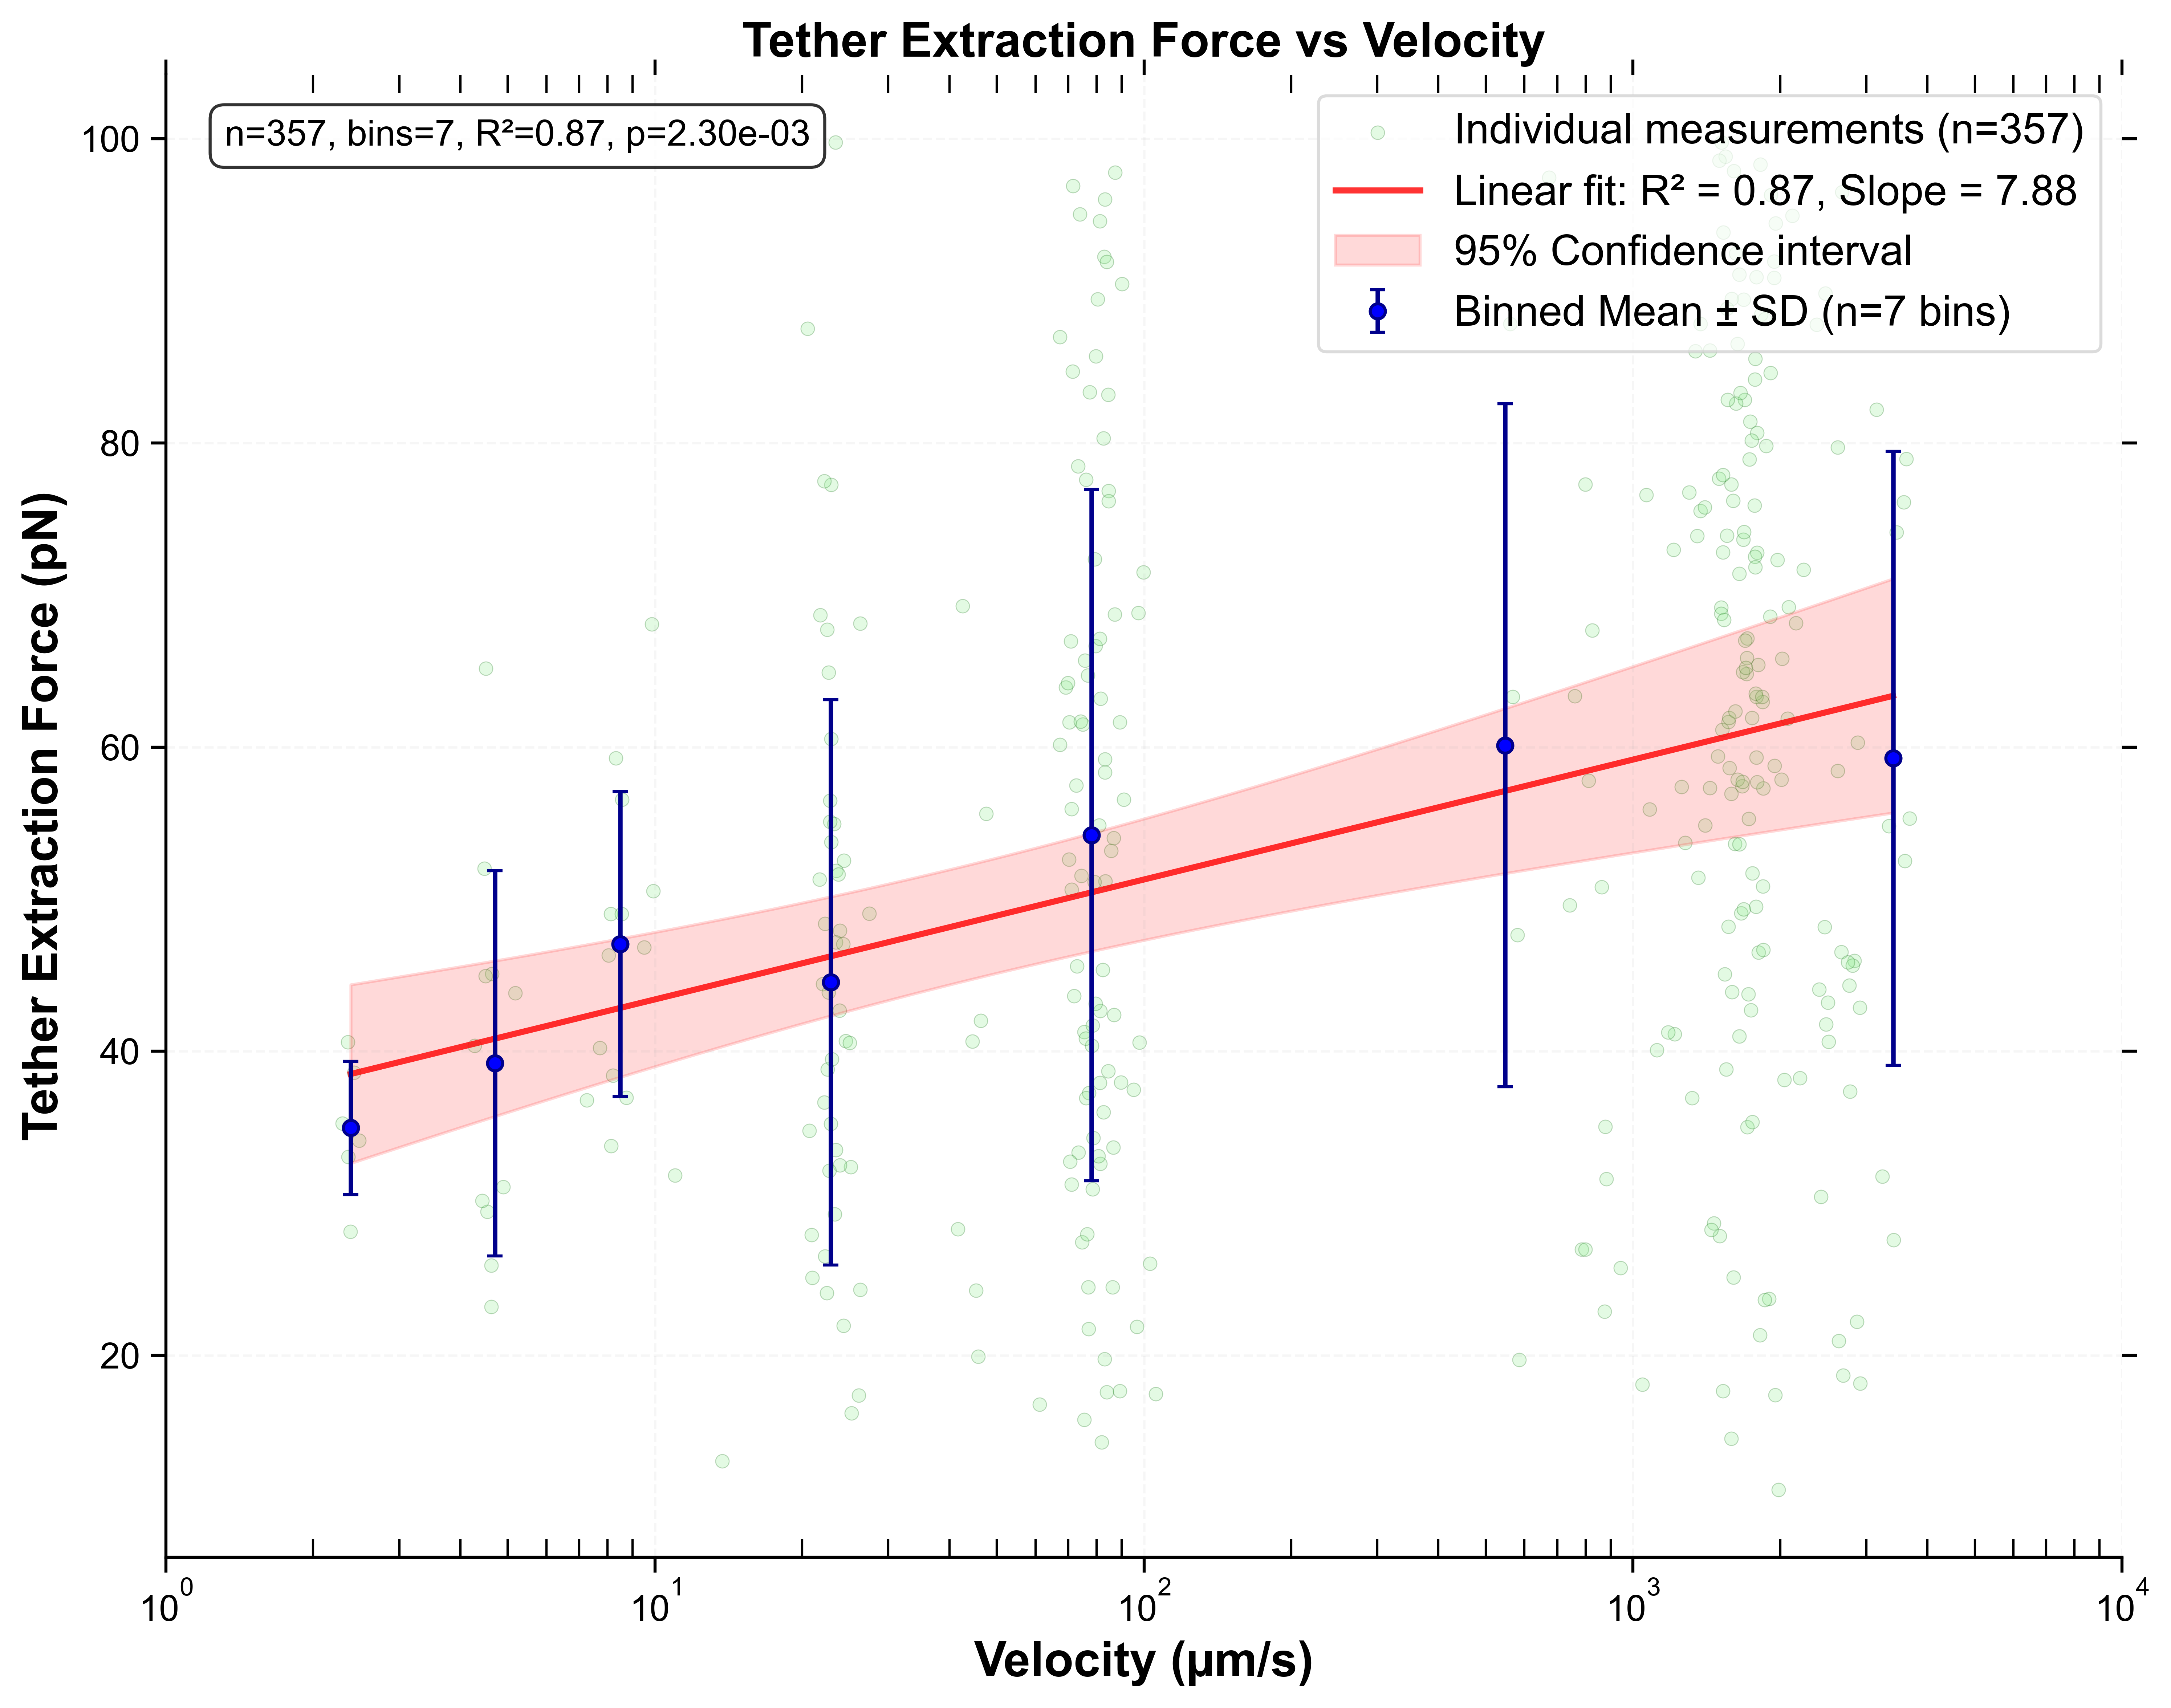

In [13]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import os
import scipy.stats as stats
from scipy.optimize import curve_fit

# Main plot - Single figure with better styling for publication
fig, ax = plt.subplots(figsize=(10, 8), dpi=600)

# 1. Scatter plot with more transparent points
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.25, s=20, color='lightgreen', edgecolors='darkgreen', linewidth=0.3,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()

# Define your custom velocity bin edges (µm/s)
# velocity_bin_edges = np.array([1, 2, 3, 6, 10 , 50, 100, 1000, 3000, 6000, 7000])
velocity_bin_edges = np.array([2, 3, 6, 10, 50, 100, 3000, 6000, 7000]) 
print(f"Data velocity range: {velocity_min:.1f} - {velocity_max:.1f} µm/s")
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]

# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()

# Filter out bins with too few points
means_df_2 = means_df_2[means_df_2['force_count'] != 23]

# 3. Plot means with error bars (standard deviation) using bin centers
# Using smaller markers and thinner error bars for publication
ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
           yerr=means_df_2['force_std'], 
           fmt='o', color='blue', markersize=5, markeredgecolor='darkblue', 
           markeredgewidth=1, ecolor='darkblue', capsize=2.5, capthick=1,
           label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)

# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'r-', linewidth=2, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.2f}, Slope = {slope_coeff:.2f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.15, color='red',
                   label='95% Confidence interval')

# Formatting for publication quality
ax.set_xlabel("Velocity (µm/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Tether Extraction Force (pN)", fontsize=16, fontweight='bold')
ax.set_title("Tether Extraction Force vs Velocity", fontsize=16, fontweight='bold')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.grid(True, alpha=0.1, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove the top and right spines (the box boundaries)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optionally, thicken x and y axes for emphasis
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)

# Make ticks point outward for a clean look
ax.tick_params(direction='out', length=5, width=1.0)


# Add more tick marks for better readability
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=14, framealpha=0.7, loc='upper right')

# Add concise statistics text - smaller and more compact for publication
stats_text = f"n={len(force_df)}, bins={len(means_df_2)}, R²={r_value**2:.2f}, p={p_value:.2e}"
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, pad=0.4))

plt.tight_layout()
plt.xlim(1, 1e4)  # Set better x limits

# save as svg file with transparent background
save_plots = True
dir_path = '/Users/evillz/Data/article/figures'

fig_path = os.path.join(dir_path, os.path.basename(filename)[:-5]+'_TetherForceVsVelocity.svg')
print(fig_path)
if save_plots:
    fig.savefig(fig_path, format='svg', dpi=600, transparent=True)
    
    # Also save in publication-ready formats
    fig.savefig(fig_path.replace('.svg', '.pdf'), format='svg', dpi=600, transparent=True)
    # fig.savefig(fig_path.replace('.svg', '.png'), format='png', dpi=600, transparent=True)
    
print(f"Force analysis complete: R²={r_value**2:.3f}, Slope={slope_coeff:.3f}, p={p_value:.3e}")


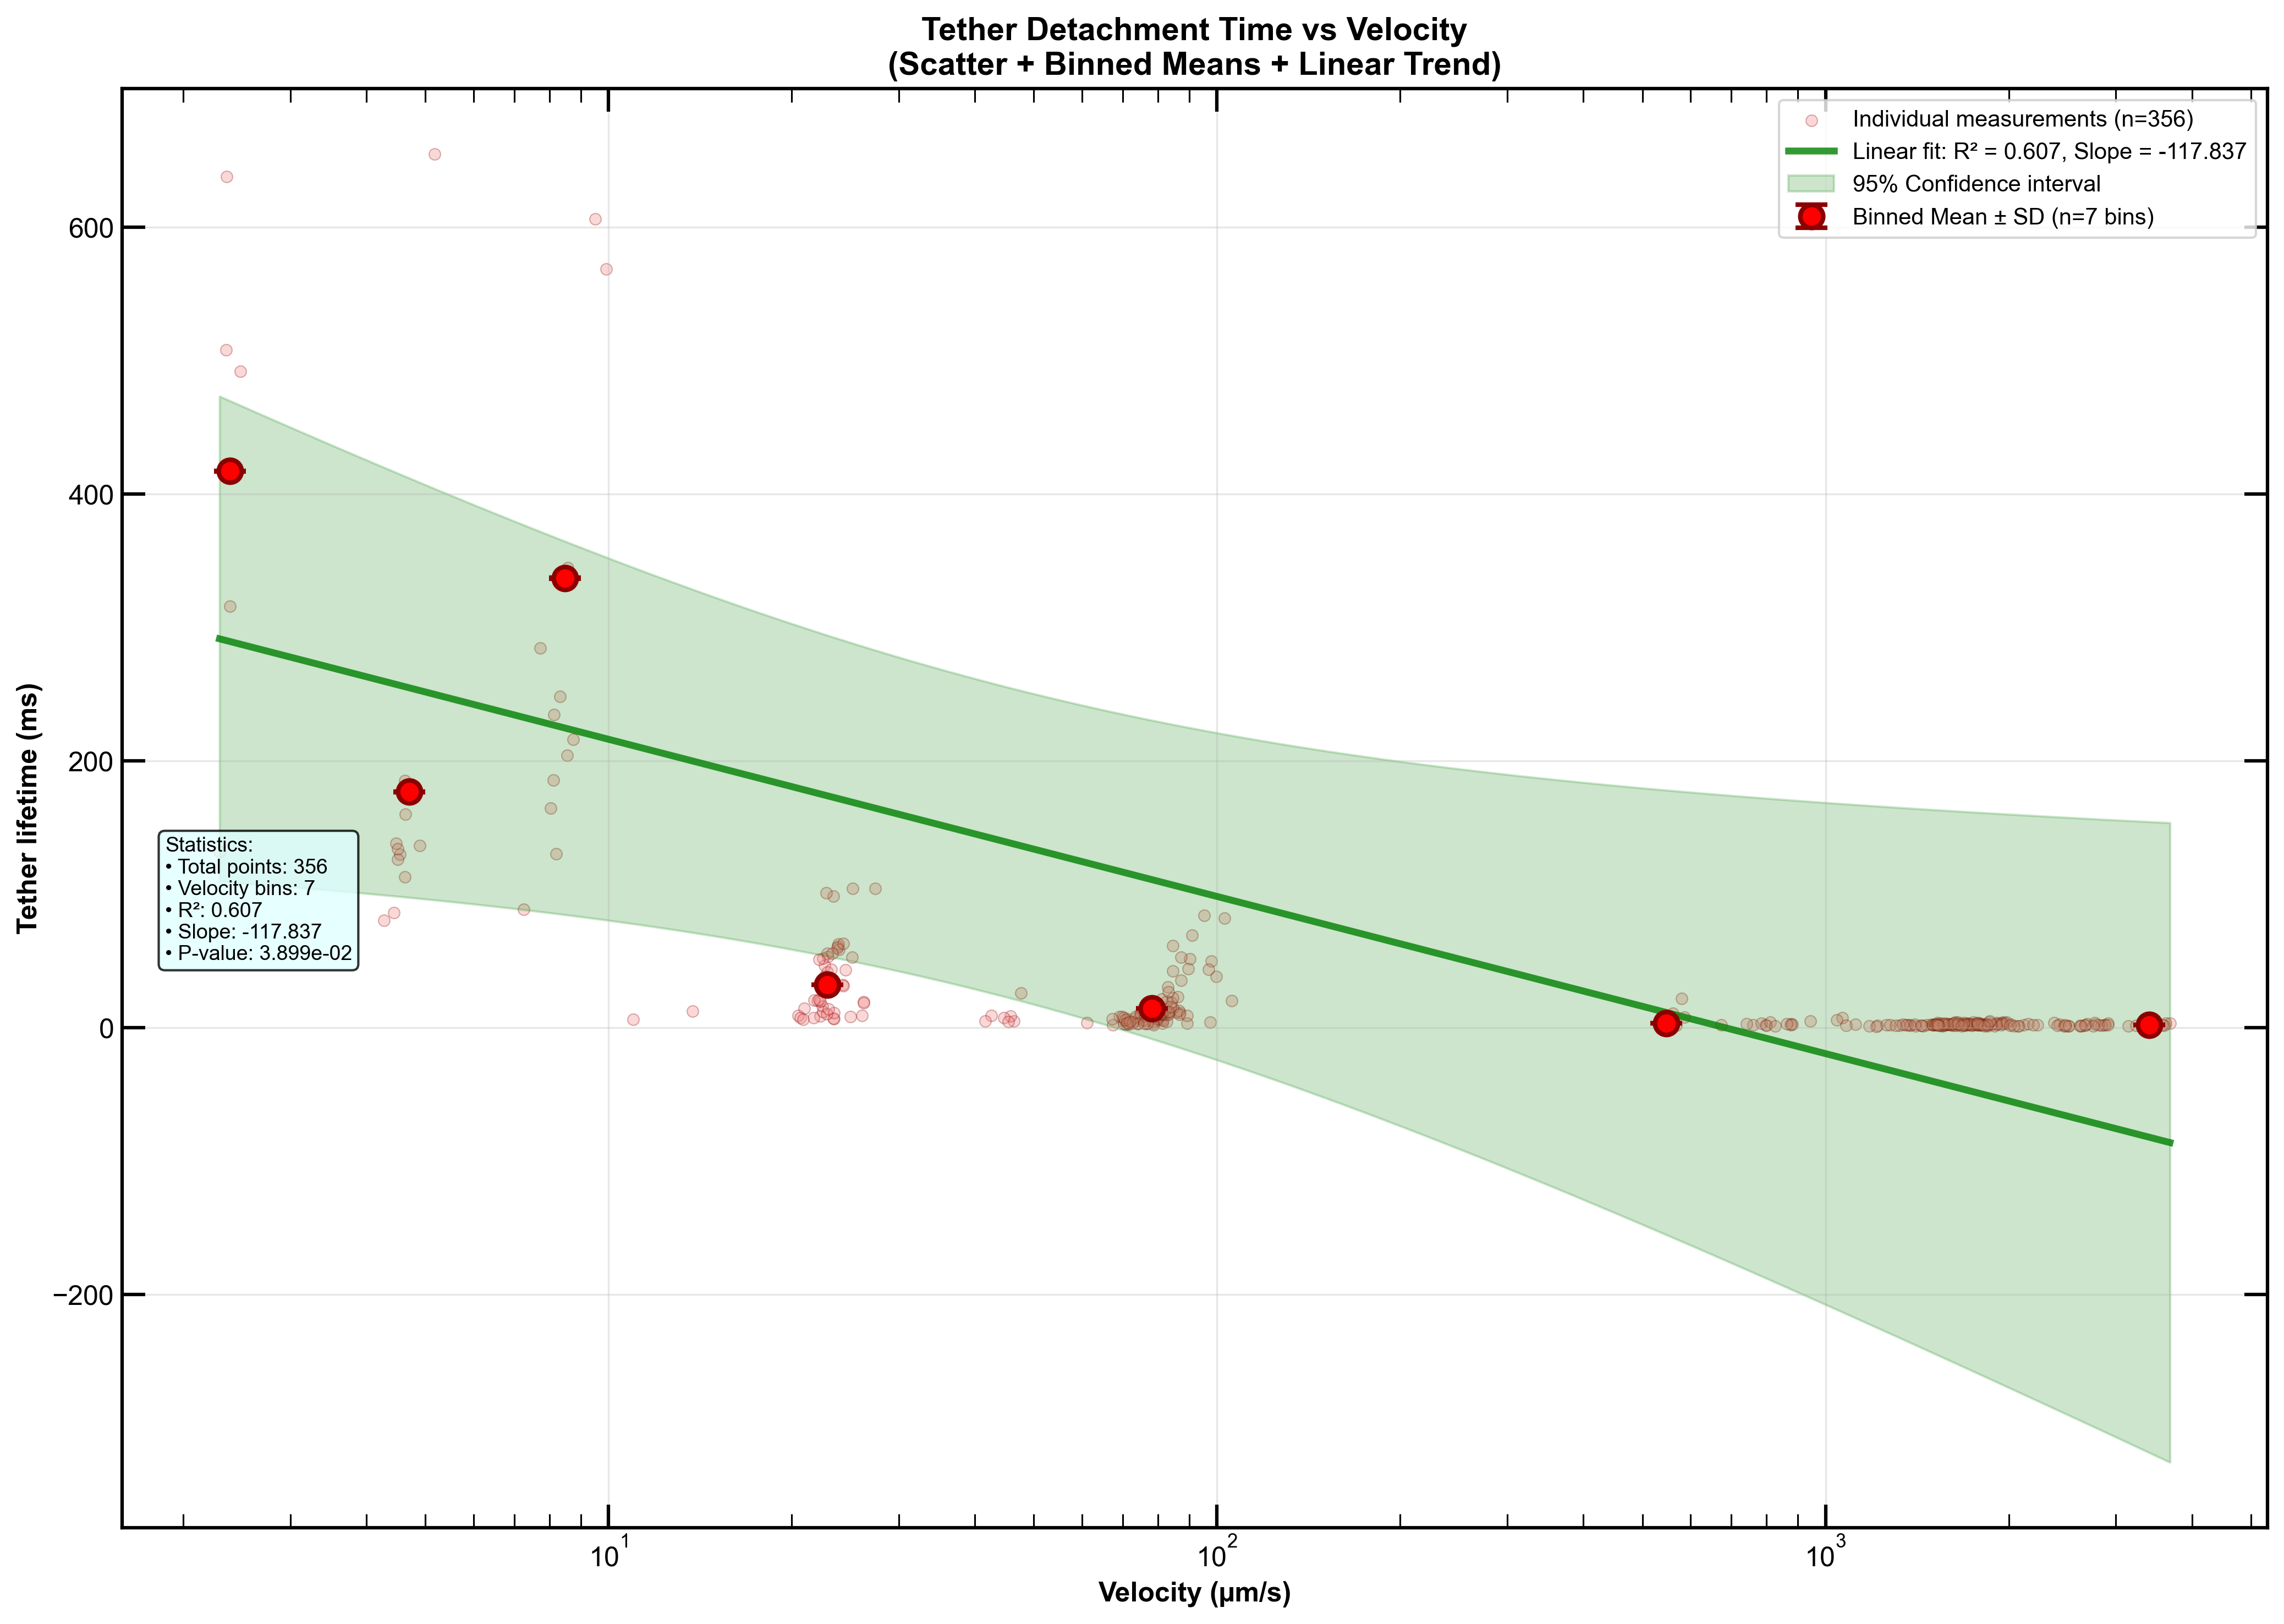

Time analysis: 356 points, 7 bins


In [14]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


means_df_3 = means_df_2.copy()

# convert liftime_s to lifetime_ms
force_df['lifetime_ms_clean'] = force_df['lifetime_s_clean'] * 1e3
means_df_3['lifetime_ms_clean_mean'] = means_df_3['lifetime_s_clean_mean'] * 1e3
means_df_3['lifetime_ms_clean_std']  = means_df_3['lifetime_s_clean_std'] * 1e3

# # Filter bins with enough data
force_df = force_df[force_df['lifetime_ms_clean'] < 1000] #filter out tethers that take more than 1 second

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['lifetime_ms_clean'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(means_df_3) > 0:
    ax.errorbar(means_df_3['velocity_bin_center'], means_df_3['lifetime_ms_clean_mean'], 
               yerr=means_df_3['lifetime_s_clean_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df_3)} bins)', zorder=5)

# 4. Fit linear trend to means

x_log = np.log10(means_df_3['velocity_bin_center'])
y_log = means_df_3['lifetime_ms_clean_mean']


slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Generate and plot trend line
# x_trend = (np.log10(vel_min), np.log10(vel_max), 100)
x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
y_trend = intercept + slope_coeff * np.log10(x_trend)

ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
        label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')

# Add confidence interval
n = len(means_df_3)
t_val = scipy_stats.t.ppf(0.975, n-2)
residuals = y_log - (intercept + slope_coeff * x_log)
mse = np.sum(residuals**2) / (n-2)

x_log_trend = np.log10(x_trend)
se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                            np.sum((x_log - np.mean(x_log))**2)))

ci_lower = y_trend - t_val * se_trend
ci_upper = y_trend + t_val * se_trend

ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                label='95% Confidence interval')


# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Time vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Velocity bins: {len(means_df_3)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Insufficient data for trend"""

ax.text(0.02, 0.48, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(force_df)} points, {len(means_df_3)} bins")

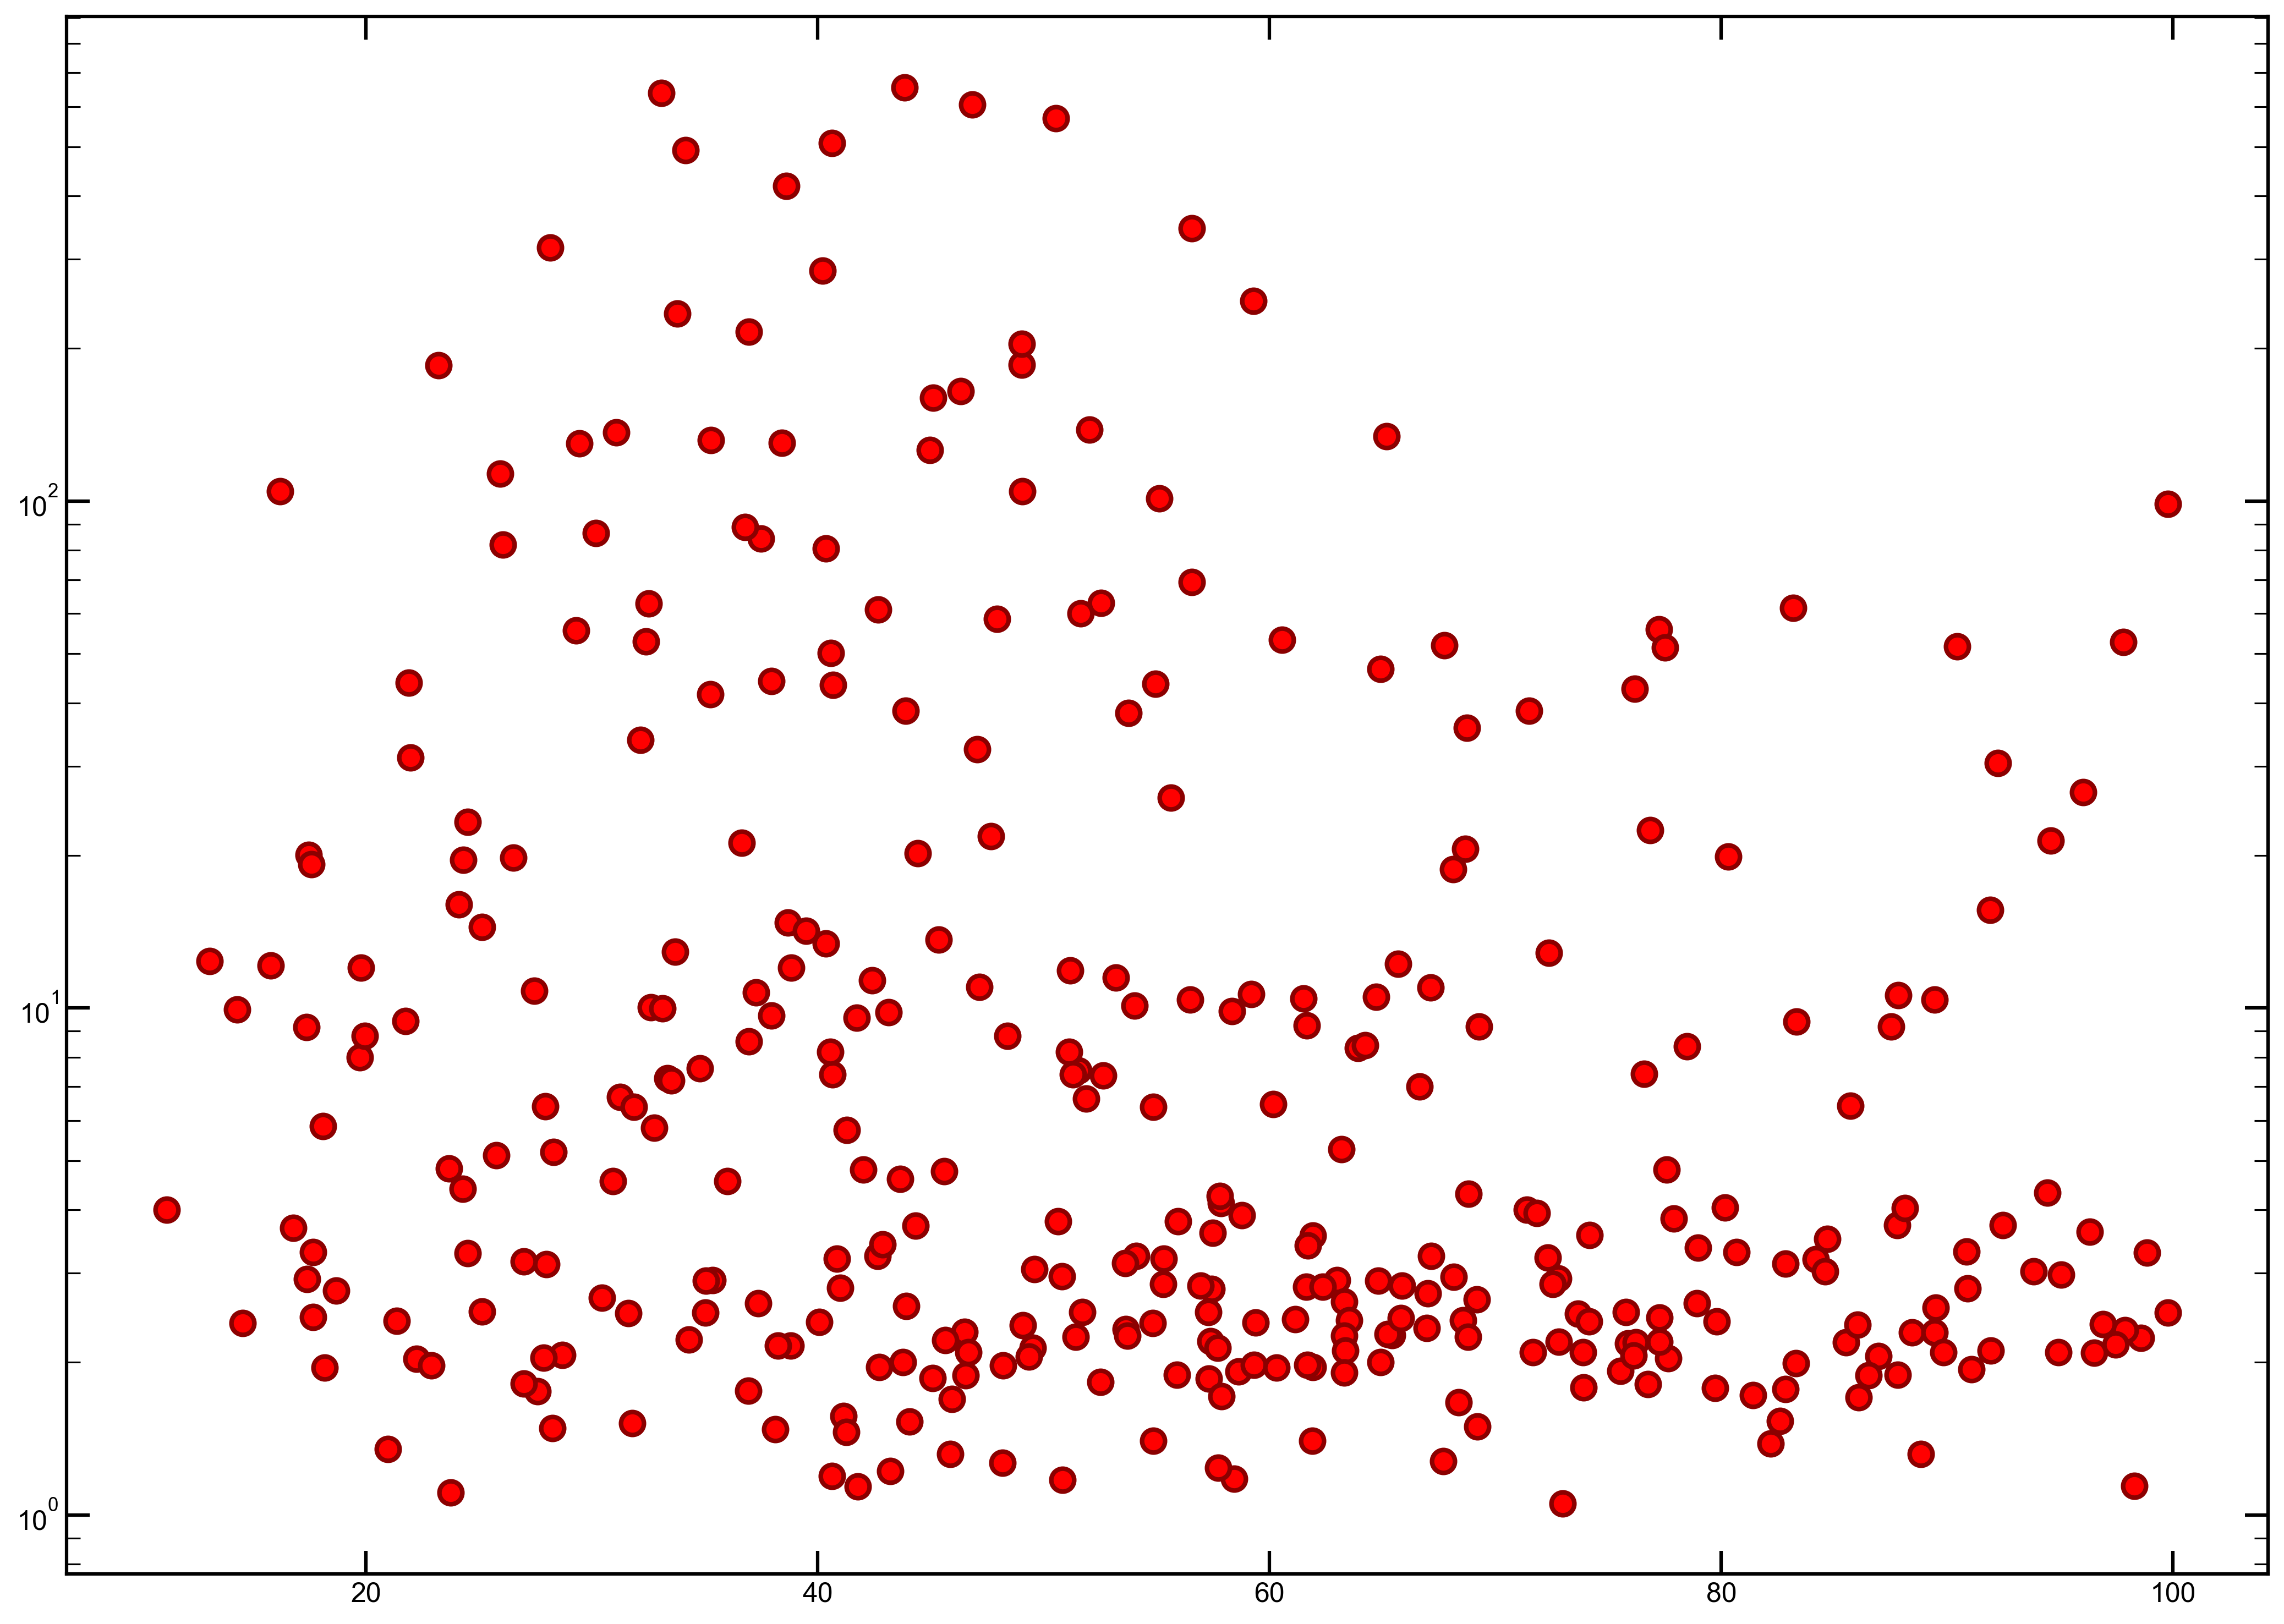

In [15]:
# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


# 1. Scatter plot of all data points
ax.scatter(force_df['force_clean'], force_df['lifetime_ms_clean'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(force_df) > 0:
    ax.errorbar(force_df['force_clean'], force_df['lifetime_ms_clean'], 
            #    yerr=force_df['lifetime_s_clean_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(force_df)} bins)', zorder=5)

plt.yscale('log')

plt.tight_layout()
plt.show()


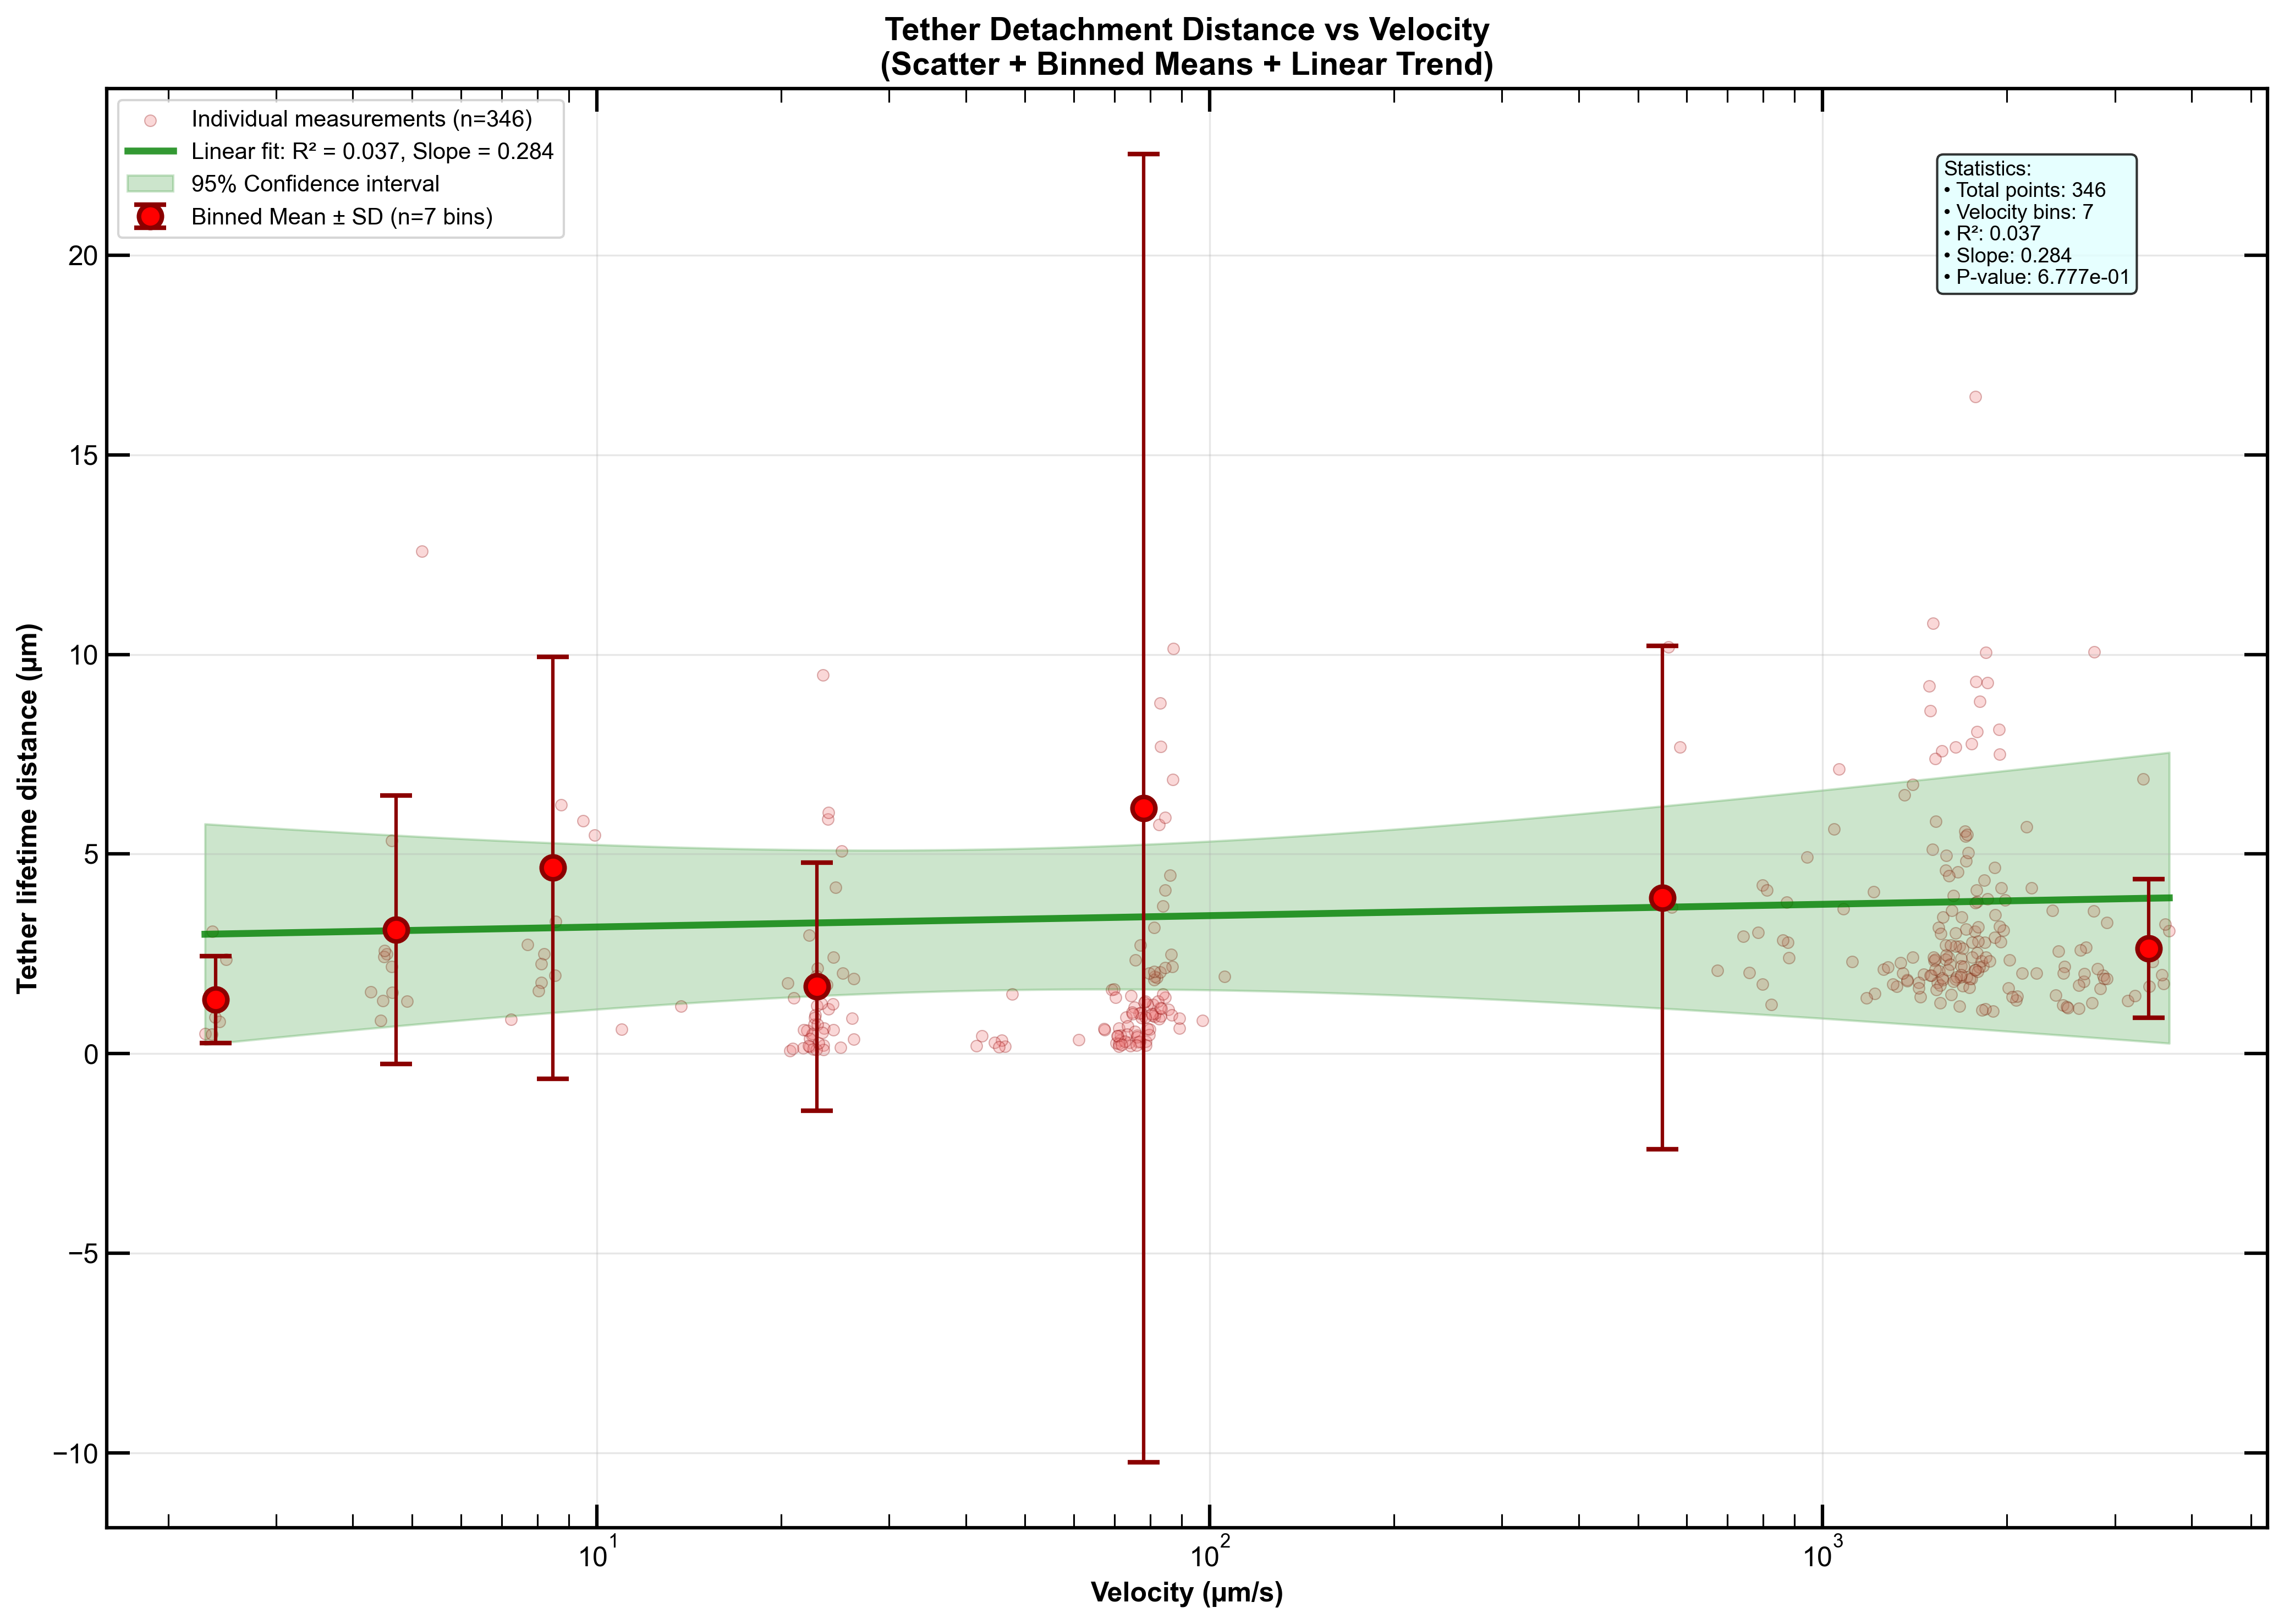

Time analysis: 346 points, 7 bins


In [16]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


means_df_4 = means_df_3.copy()
scale_um = 1e6

# convert liftime_s to lifetime_m
force_df['lifetime_mm_clean'] = force_df['lifetime_m_clean'] 
means_df_3['lifetime_mm_clean_mean'] = means_df_3['lifetime_m_clean_mean'] 
means_df_3['lifetime_m_clean_std']  = means_df_3['lifetime_m_clean_std'] 

# # Filter bins with enough data
force_df = force_df[force_df['lifetime_mm_clean']* scale_um < 20]

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['lifetime_mm_clean'] * scale_um, 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(means_df_3) > 0:
    ax.errorbar(means_df_3['velocity_bin_center'], means_df_3['lifetime_mm_clean_mean']* scale_um, 
               yerr=means_df_3['lifetime_m_clean_std']* scale_um, 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df_3)} bins)', zorder=5)

# 4. Fit linear trend to means

x_log = np.log10(means_df_3['velocity_bin_center'])
y_log = means_df_3['lifetime_mm_clean_mean']* scale_um


slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Generate and plot trend line
# x_trend = (np.log10(vel_min), np.log10(vel_max), 100)
x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
y_trend = intercept + slope_coeff * np.log10(x_trend)

ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
        label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')

# Add confidence interval
n = len(means_df_3)
t_val = scipy_stats.t.ppf(0.975, n-2)
residuals = y_log - (intercept + slope_coeff * x_log)
mse = np.sum(residuals**2) / (n-2)

x_log_trend = np.log10(x_trend)
se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                            np.sum((x_log - np.mean(x_log))**2)))

ci_lower = y_trend - t_val * se_trend
ci_upper = y_trend + t_val * se_trend

ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                label='95% Confidence interval')


# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether lifetime distance (µm)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Distance vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
# ax.set_ylim(bottom=-1)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Velocity bins: {len(means_df_3)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Insufficient data for trend"""

ax.text(0.85, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(force_df)} points, {len(means_df_3)} bins")

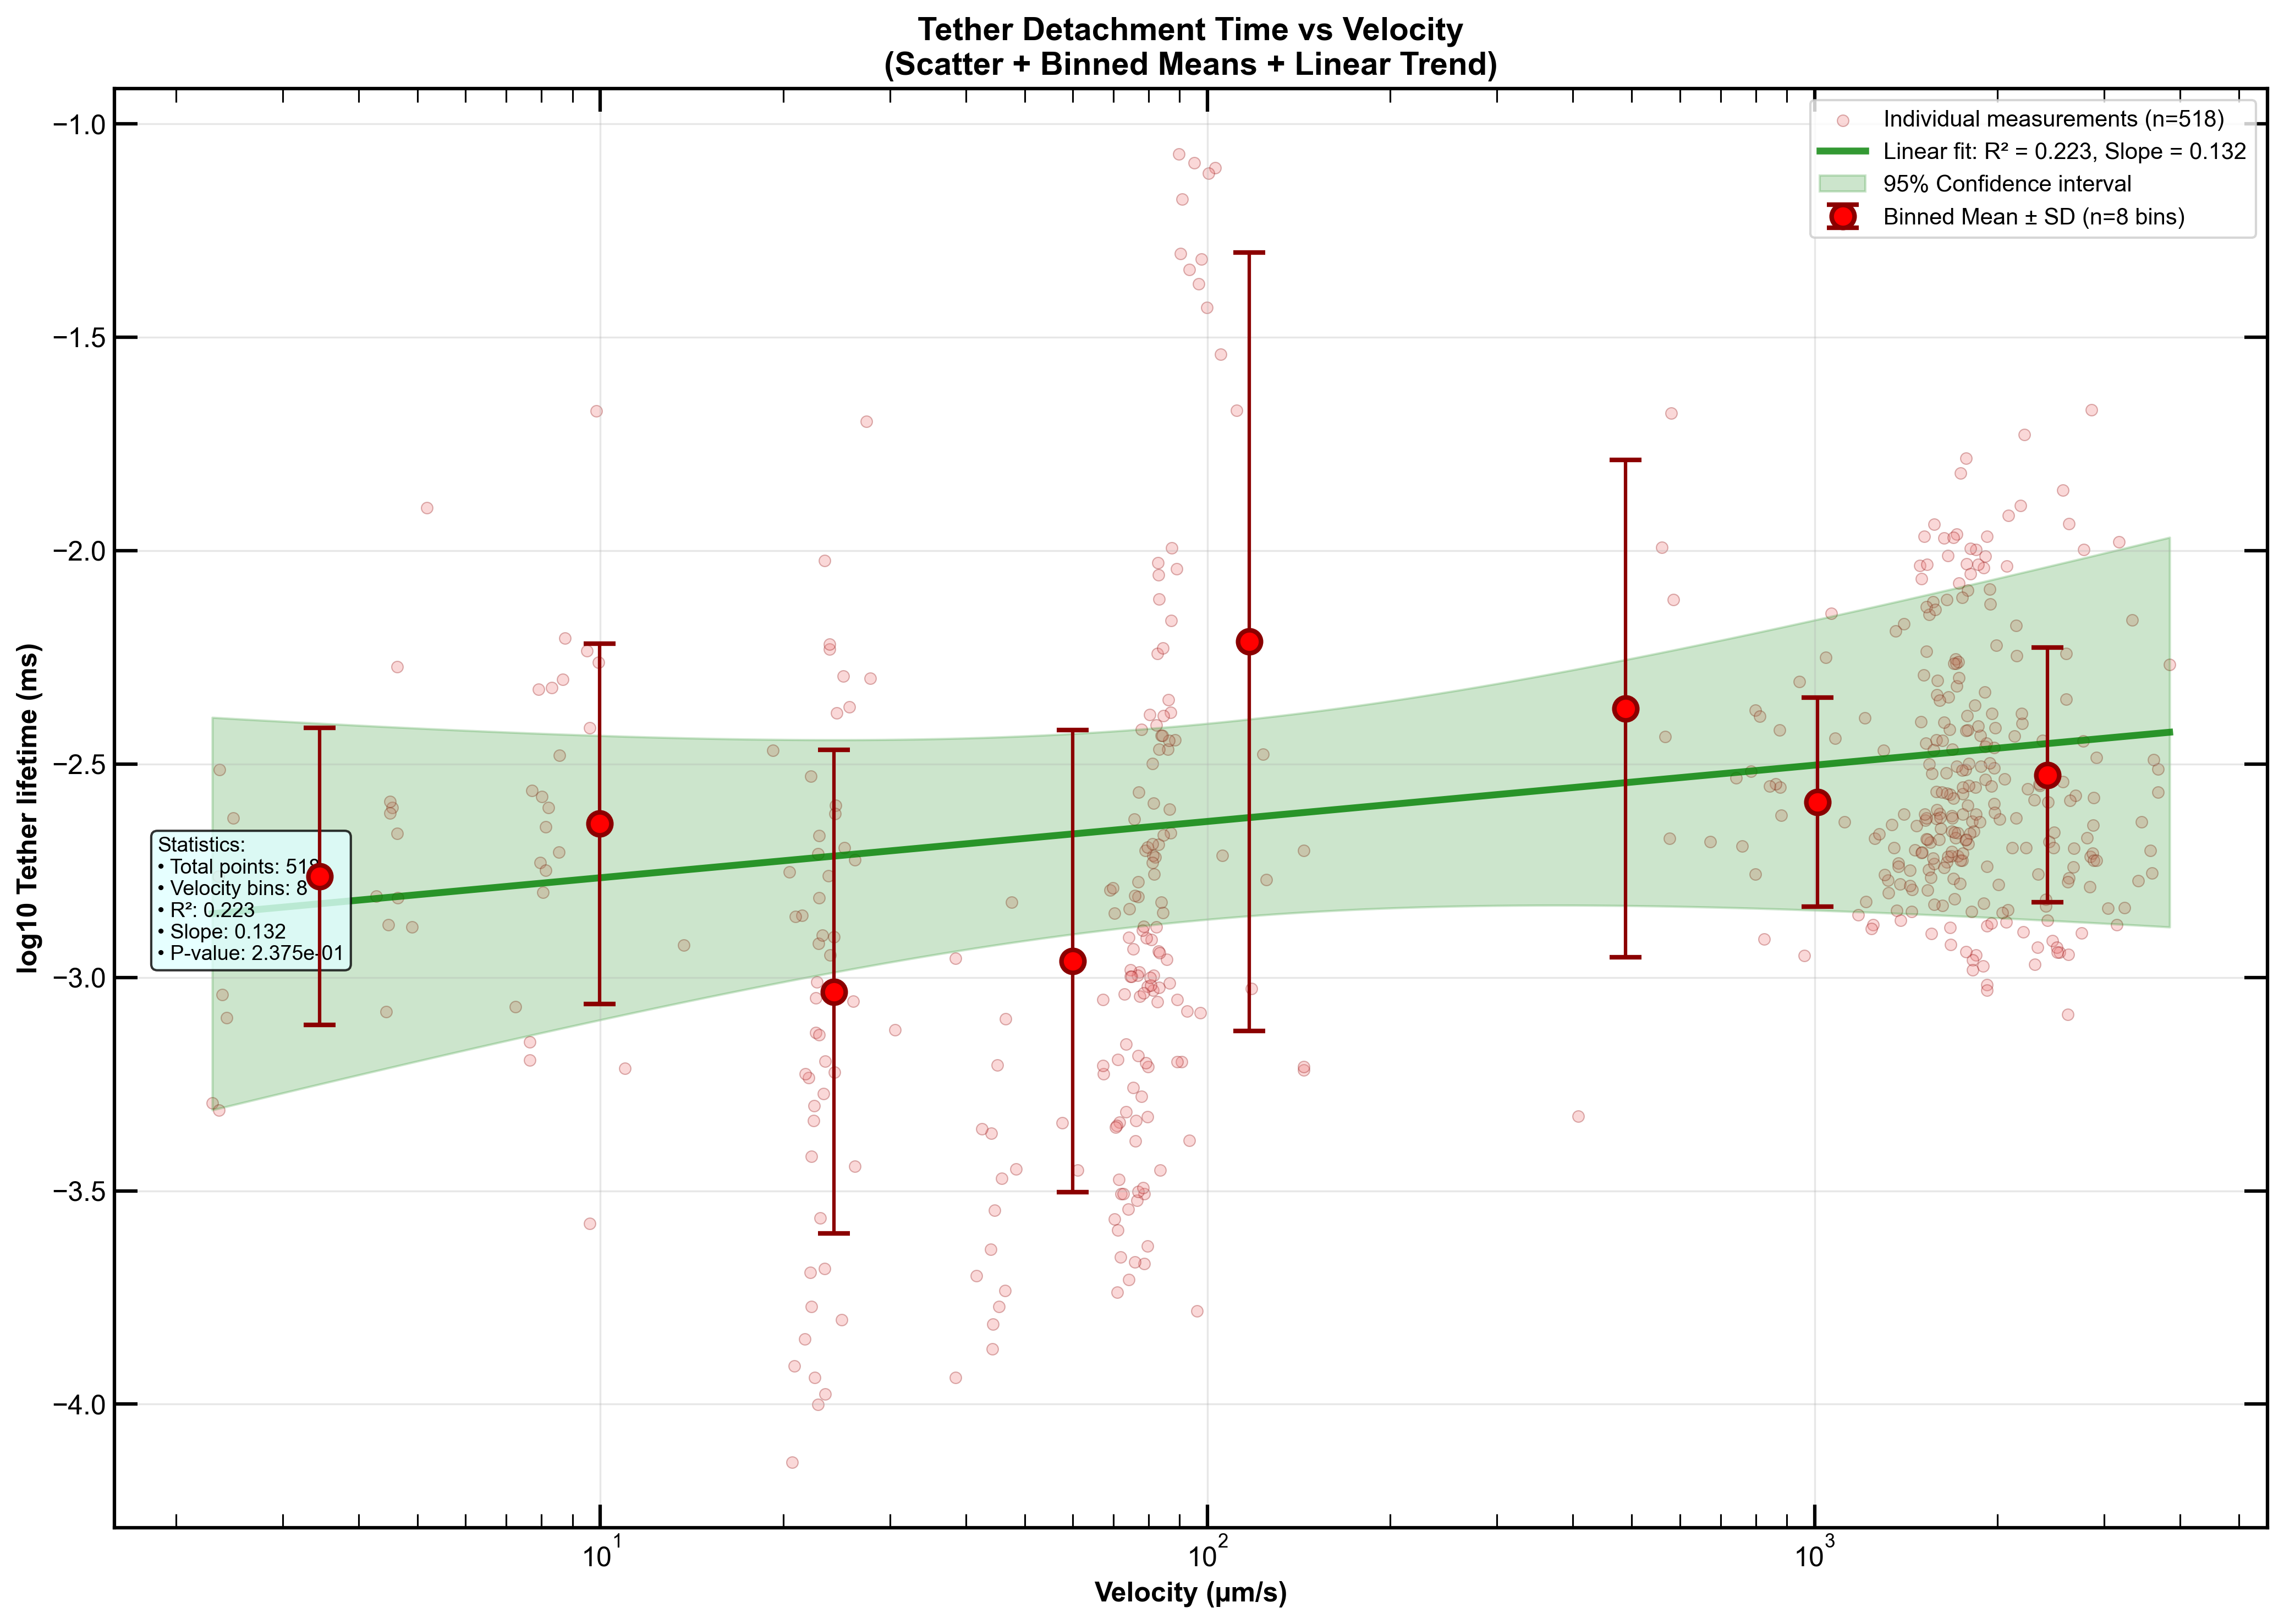

Time analysis: 518 points, 8 bins


In [17]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Filter and prepare time data
velocity_filtered = np.array(selected_velocity_calc)
time_filtered = np.array(selected_tether_lifetime_m)

# Basic data filtering
valid_mask = (
    ~np.isnan(velocity_filtered) & 
    ~np.isnan(time_filtered) &
    (velocity_filtered > 1e-6) &
    (time_filtered > 0)
)

velocity_filtered = velocity_filtered[valid_mask]
time_filtered = time_filtered[valid_mask]
time_log = safe_log10(time_filtered * 1e3)  # Convert to ms

# Remove infinite values
finite_mask = np.isfinite(time_log)
velocity_filtered = velocity_filtered[finite_mask]
time_log = time_log[finite_mask]

# Create DataFrame
time_df = pd.DataFrame({
    'velocity': velocity_filtered,
    'time_log': time_log
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(time_df['velocity'], time_df['time_log'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(time_df)})')

# 2. Create velocity bins and calculate means
num_bins = 8
velocity_min, velocity_max = time_df['velocity'].min(), time_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
time_df['bin_idx'] = np.digitize(time_df['velocity'], bin_edges) - 1
time_df['bin_idx'] = np.clip(time_df['bin_idx'], 0, num_bins - 1)

means_df = time_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    time_mean=('time_log', 'mean'),
    time_std=('time_log', 'std'),
    count=('time_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 1]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['time_mean'], 
               yerr=means_df['time_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)

# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['time_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Time vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Insufficient data for trend"""

ax.text(0.02, 0.48, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(time_df)} points, {len(means_df)} bins")

In [18]:
delta_avg_clean = np.array(selected_delta_avg)
selected_tether_lifetime_s_clean = np.array(selected_tether_lifetime_s)

valid_mask = (
    ~np.isnan(delta_avg_clean) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12)       # <1000 pN
)

force_filtered = delta_avg_clean[valid_mask]
selected_tether_lifetime_s_clean_filtered = selected_tether_lifetime_s_clean[valid_mask]
force_abs_pN = np.abs(force_filtered) * 1e12 # change to pN
selected_tether_lifetime_s_clean_filtered_ms = selected_tether_lifetime_s_clean_filtered * 1e3


# Remove infinite values
finite_mask =  np.isfinite(force_abs_pN)
force_abs_clean = force_abs_pN[finite_mask]
selected_tether_lifetime_s_clean_filtered_ms_clean = selected_tether_lifetime_s_clean_filtered_ms[finite_mask]


# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity': velocity_clean,
    'velocity_log': velocity_log_clean,
    'force_log': force_log_clean
})

###%####
# 5. Tether lifetime vs tether extraction force (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

# Create DataFrame for analysis
force_bins_df = pd.DataFrame({
    'force_log': safe_log10(force_abs_clean),  
    'lifetime_log': safe_log10(selected_tether_lifetime_s_clean_filtered_ms_clean)
})

# Remove invalid log values
force_bins_df = force_bins_df[np.isfinite(force_bins_df['force_log']) & np.isfinite(force_bins_df['lifetime_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(force_bins_df['force_log'], force_bins_df['lifetime_log'], 
          alpha=0.3, s=25, color='plum', edgecolors='purple', linewidth=0.5,
          label=f'Individual measurements (n={len(force_bins_df)})')

# 2. Create force bins and calculate means and standard deviations
force_min = force_bins_df['force_log'].min()
force_max = force_bins_df['force_log'].max()
num_force_bins = 5

# Create evenly spaced bin edges for force
force_bin_edges = np.linspace(force_min, force_max, num_force_bins + 1)

# Assign each point to a force bin
force_bins_df['force_bin_idx'] = np.digitize(force_bins_df['force_log'], force_bin_edges) - 1
force_bins_df['force_bin_idx'] = np.clip(force_bins_df['force_bin_idx'], 0, num_force_bins - 1)

# Calculate binned means and standard deviations
means_df_force = force_bins_df.groupby('force_bin_idx').agg(
    force_mean=('force_log', 'mean'),
    force_bin_center=('force_log', lambda x: (x.min() + x.max()) / 2),
    lifetime_mean=('lifetime_log', 'mean'),
    lifetime_std=('lifetime_log', 'std'),
    lifetime_count=('lifetime_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_force = means_df_force[means_df_force['lifetime_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_force['force_bin_center'], means_df_force['lifetime_mean'], 
           yerr=means_df_force['lifetime_std'], 
           fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
           markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_force)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_force) > 3:
    force_log_means = means_df_force['force_bin_center']
    lifetime_log_means = means_df_force['lifetime_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        force_log_means, lifetime_log_means)
    
    # Generate trend line
    force_trend = np.linspace(means_df_force['force_bin_center'].min(), 
                             means_df_force['force_bin_center'].max(), 100)
    lifetime_trend = intercept + slope_coeff * force_trend
    
    ax.plot(force_trend, lifetime_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_force)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = lifetime_log_means - (intercept + slope_coeff * force_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (force_trend - np.mean(force_log_means))**2 / 
                             np.sum((force_log_means - np.mean(force_log_means))**2)))
    
    ci_lower = lifetime_trend - t_val * se_trend
    ci_upper = lifetime_trend + t_val * se_trend
    
    ax.fill_between(force_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Tether Force (pN)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Lifetime vs Tether Extraction Force\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(force_bins_df)}
• Force bins: {len(means_df_force)}
• Force range: {10**means_df_force['force_bin_center'].min():.1f} - {10**means_df_force['force_bin_center'].max():.1f} pN
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.01, 0.99, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='thistle', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Force-lifetime analysis complete:")
print(f"  - Individual data points: {len(force_bins_df)}")
print(f"  - Force bins used for trend: {len(means_df_force)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")

NameError: name 'velocity_log_clean' is not defined

In [ ]:
# Remove NaN values from all arrays before binning
loading_rate_array = np.array(loading_rate)
rupture_slope_array = np.array(rupture_slope_arr)
print(f'len(loading_rate_array): {len(loading_rate_array)}')
valid_mask = ~(np.isnan(loading_rate_array) | np.isnan(rupture_slope_array))
print(f"Valid data points for loading rate and rupture slope: {np.sum(valid_mask)}")
loading_rate_array_clean = loading_rate_array
rupture_slope_array_clean = rupture_slope_array

#  Sort loading rate in ascending order
sorted_loading_rate_indices = np.argsort(loading_rate_array_clean)
loading_rate_sorted = loading_rate_array_clean[sorted_loading_rate_indices]
rupture_slope_array_clean = rupture_slope_array_clean[sorted_loading_rate_indices]  
# 6. Rupture Force vs Loading Rate (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

print (f'len_loading_rate_array: {len(loading_rate_array)}')
print (f'len_rupture_slope_array: {len(rupture_slope_array)}')

# Create DataFrame for analysis
loading_bins_df = pd.DataFrame({
    'loading_rate_log': safe_log10(loading_rate_array * 1e12),  # Convert to pN/s
    'rupture_slope_log': (rupture_slope_array)  # Convert to pN
})

# Remove invalid log values
loading_bins_df = loading_bins_df[np.isfinite(loading_bins_df['loading_rate_log']) & np.isfinite(loading_bins_df['rupture_slope_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(loading_bins_df['loading_rate_log'], loading_bins_df['rupture_slope_log'], 
          alpha=0.3, s=25, color='lightsteelblue', edgecolors='darkblue', linewidth=0.5,
          label=f'Individual measurements (n={len(loading_bins_df)})')

# 2. Create loading rate bins and calculate means and standard deviations
loading_min = loading_bins_df['loading_rate_log'].min()
loading_max = loading_bins_df['loading_rate_log'].max()
num_loading_bins = 5

# Create evenly spaced bin edges for loading rate
loading_bin_edges = np.linspace(loading_min, loading_max, num_loading_bins + 1)

# Assign each point to a loading rate bin
loading_bins_df['loading_bin_idx'] = np.digitize(loading_bins_df['loading_rate_log'], loading_bin_edges) - 1
loading_bins_df['loading_bin_idx'] = np.clip(loading_bins_df['loading_bin_idx'], 0, num_loading_bins - 1)

# Calculate binned means and standard deviations
means_df_loading = loading_bins_df.groupby('loading_bin_idx').agg(
    loading_mean=('loading_rate_log', 'mean'),
    loading_bin_center=('loading_rate_log', lambda x: (x.min() + x.max()) / 2),
    force_mean=('rupture_slope_log', 'mean'),
    force_std=('rupture_slope_log', 'std'),
    force_count=('rupture_slope_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_loading = means_df_loading[means_df_loading['force_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_loading['loading_bin_center'], means_df_loading['force_mean'], 
           yerr=means_df_loading['force_std'], 
           fmt='o', color='darkblue', markersize=10, markeredgecolor='navy', 
           markeredgewidth=2, ecolor='navy', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_loading)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_loading) > 3:
    loading_log_means = means_df_loading['loading_bin_center']
    rupture_slope_log_means = means_df_loading['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        loading_log_means, rupture_slope_log_means)
    
    # Generate trend line
    loading_trend = np.linspace(means_df_loading['loading_bin_center'].min(), 
                               means_df_loading['loading_bin_center'].max(), 100)
    force_trend = intercept + slope_coeff * loading_trend
    
    ax.plot(loading_trend, force_trend, 'darkorange', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_loading)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = rupture_slope_log_means - (intercept + slope_coeff * loading_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (loading_trend - np.mean(loading_log_means))**2 / 
                             np.sum((loading_log_means - np.mean(loading_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(loading_trend, ci_lower, ci_upper, alpha=0.2, color='darkorange',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Loading Rate (pN/s)", fontsize=16, fontweight='bold')
ax.set_ylabel("Rupture Force (pN)", fontsize=16, fontweight='bold')
ax.set_title("Rupture Force vs Loading Rate\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(loading_bins_df)}
• Loading rate bins: {len(means_df_loading)}
• Loading rate range: {10**means_df_loading['loading_bin_center'].min():.1f} - {10**means_df_loading['loading_bin_center'].max():.1f} pN/s
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.7, 0.2, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Loading rate analysis complete:")
print(f"  - Individual data points: {len(loading_bins_df)}")
print(f"  - Loading rate bins used for trend: {len(means_df_loading)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")

In [ ]:
import matplotlib.pyplot as plt

# Suppose your DataFrame is called df and you want to plot a histogram of the 'velocity' column:
plt.figure(figsize=(8, 5))
plt.hist(loading_bins_df['loading_rate_log'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('loading_rate_log')
plt.ylabel('Count')
plt.title('Histogram of loading_rate_log')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Suppose your DataFrame is called df and you want to plot a histogram of the 'velocity' column:
plt.figure(figsize=(8, 5))
plt.hist(loading_bins_df['rupture_slope_log'], bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('rupture_slope_log')
plt.ylabel('Count')
plt.title('Histogram of rupture_slope_log')
plt.show()